# ECB Shock Regressions – Thesis-Grade Specification

This notebook implements ECB monetary policy shock × equity duration regressions
with all econometric corrections applied:

- **Intercept restored**: formulas use `~ rhs` not `~ 0 + rhs` (bias fix for Models 1–3, 5)
- **Raw shock levels** always included in non-Event-FE specs (absorb average shock effect unrelated to duration)
- **Sample std (ddof=1)** for cross-sectional z-scores (standard econometric convention)
- **EPP_NP** (Expected Payback Period, undiscounted) added as third duration measure
- **bm** (book-to-market) added as control in Model 4 only (prevents collinearity without Event FE)
- **n_clusters safety check**: warning if < 30 event clusters
- **Pre-regression diagnostics**: shock orthogonality, coverage by year, return monotonicity, multicollinearity
- **Extended robustness**: shock magnitude subsamples, time subsamples (pre/post GFC and QE),
  influential-event exclusion, winsorized returns
- **Joint Wald test** for H0: β_MP_duration = 0 AND β_Info_duration = 0
- **Professional LaTeX table** (booktabs, Panel A / Panel B, standard errors, stars)

## 0. Variable Naming (Short Guide)

Dependent variables:
- `AR_0`: event-day abnormal return
- `AR_0_1`: event-day plus next-day abnormal return
- `AR_0_wins`: AR_0 winsorized at 1%/99% per event date (robustness)
- `AR_m1_1`: placebo window from previous day to next day (if available)

Shock variables:
- `ShockMP`: monetary-policy shock (`MP_median`)
- `ShockInfo`: information shock (`CBI_median`)

Duration variables (all standardized cross-sectionally by year, ddof=1):
- `Duration_Implied_std`: DSS-style implied equity duration
- `Duration_NetPayout_std`: Gonçalves VAR-based net payout duration
- `EPP_std`: Expected Payback Period (undiscounted, from Robustness parquet)
- `SY_gross_std`, `SY_div_only_std`, `BM_rob_std`, `EP_rob_std`: Robustness duration measures

Controls (if available and standardized):
- `beta_std`
- `log_mcap_std`
- `leverage_std`
- `bm_std` (book-to-market; Model 4 only — Event FE prevents collinearity with duration)

## 1. Load data

In [28]:
import numpy as np
import pandas as pd
from pathlib import Path
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from plot_style import COLORS, set_global_plot_style, style_axes, style_legend, style_time_axis

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

from project_paths import BASE_DIR, DATA_DIR, CACHE_DATA_DIR
TABLE_DIR = BASE_DIR / 'tables'
GRAPH_DIR = BASE_DIR / 'graphs' / 'ECBShocks_Equities_Regressions'
GRAPH_DIR.mkdir(parents=True, exist_ok=True)

RET_PATH = DATA_DIR / 'euro500_daily_returns.parquet'
SHOCK_PATH = DATA_DIR / 'shocks_ecb_mpd_me_d.csv'
DUR_IMP_PATH = DATA_DIR / 'EQDuration_Implied.parquet'
DUR_NP_PATH = DATA_DIR / 'EQDuration_Netpayout.parquet'
DUR_ROB_PATH = DATA_DIR / 'EQDuration_Robustness.parquet'
EURO500_PATH = DATA_DIR.parent / 'intermediate' / 'euro500.parquet'

for p in [RET_PATH, SHOCK_PATH, DUR_IMP_PATH, DUR_NP_PATH, DUR_ROB_PATH]:
    if not p.exists():
        raise FileNotFoundError(f'Missing required input: {p}')

df_ret = pd.read_parquet(RET_PATH)
df_shock = pd.read_csv(SHOCK_PATH)
df_imp = pd.read_parquet(DUR_IMP_PATH)
df_np = pd.read_parquet(DUR_NP_PATH)
df_rob = pd.read_parquet(DUR_ROB_PATH)
print(f"Robustness shape: {df_rob.shape}")
print(f"Columns: {list(df_rob.columns)}")

# Load sector mapping and build non-financials set
_euro500 = pd.read_parquet(EURO500_PATH)[['firm_id', 'trbc_sector']].drop_duplicates('firm_id')
NON_FINANCIAL_FIRMS = set(
    _euro500.loc[_euro500['trbc_sector'].astype('string').str.strip() != 'Financials', 'firm_id']
)
print(f'Sector filter: {len(NON_FINANCIAL_FIRMS)} non-financial firms '
      f'(excluded {len(_euro500) - len(NON_FINANCIAL_FIRMS)} Financials)')

print('Loaded shapes:')
print('returns   :', df_ret.shape)
print('shocks    :', df_shock.shape)
print('implied   :', df_imp.shape)
print('netpayout :', df_np.shape)
print('robustness:', df_rob.shape)

set_global_plot_style()

Robustness shape: (15076, 17)
Columns: ['firm_id', 'year', 'ME_t', 'SY_gross', 'SY_div_only', 'BM', 'EP', 'EPP', 'SY_gross_w', 'SY_div_only_w', 'BM_w', 'EP_w', 'EPP_w', 'flag_sy_negative', 'flag_sy_buybacks_missing', 'flag_epp_extrapolated', 'n_measures_available']
Sector filter: 1083 non-financial firms (excluded 165 Financials)
Loaded shapes:
returns   : (3457796, 15)
shocks    : (312, 7)
implied   : (12325, 44)
netpayout : (15076, 29)
robustness: (15076, 17)


## 2. Prepare event panel

In [29]:
def first_existing(df, candidates, required=False, label='column'):
    col = next((c for c in candidates if c in df.columns), None)
    if required and col is None:
        raise KeyError(f'Missing {label}. Tried: {candidates}')
    return col

def merge_last_available_feature(events, features, value_col, event_date_col='date', feature_date_col='asof_effective_date', key_priority=('RIC', 'firm_id')):
    key = next((k for k in key_priority if k in events.columns and k in features.columns), None)
    if key is None:
        raise ValueError(f'No common merge key for {value_col}. Tried {key_priority}')

    left = events.copy()
    left[event_date_col] = pd.to_datetime(left[event_date_col], errors='coerce').dt.normalize()
    left['_row_order'] = np.arange(len(left))

    right = features[[key, feature_date_col, value_col]].copy()
    right[feature_date_col] = pd.to_datetime(right[feature_date_col], errors='coerce').dt.normalize()

    valid_left = left[event_date_col].notna() & left[key].notna()
    valid_right = right[feature_date_col].notna() & right[key].notna() & right[value_col].notna()
    l_ok = left.loc[valid_left].copy()
    r_ok = right.loc[valid_right].copy()

    if l_ok.empty or r_ok.empty:
        left[value_col] = np.nan
        return left.drop(columns=['_row_order']), key

    chunks = []
    for k_val, l_grp in l_ok.groupby(key, sort=False):
        r_grp = r_ok[r_ok[key] == k_val].sort_values(feature_date_col)
        if r_grp.empty:
            l_grp[value_col] = np.nan
            chunks.append(l_grp)
            continue
        l_grp = l_grp.sort_values(event_date_col)
        merged = pd.merge_asof(
            l_grp,
            r_grp[[feature_date_col, value_col]],
            left_on=event_date_col,
            right_on=feature_date_col,
            direction='backward',
            allow_exact_matches=True,
        )
        chunks.append(merged.drop(columns=[feature_date_col], errors='ignore'))

    out_ok = pd.concat(chunks, axis=0) if chunks else l_ok.copy()
    left = left.merge(out_ok[['_row_order', value_col]], on='_row_order', how='left')
    left = left.sort_values('_row_order').drop(columns=['_row_order'])
    return left, key


def merge_strict_quarter_feature(events, features, value_col, event_date_col='date', feature_date_col='asof_effective_date', key_priority=('RIC', 'firm_id')):
    key = next((k for k in key_priority if k in events.columns and k in features.columns), None)
    if key is None:
        raise ValueError(f'No common merge key for {value_col}. Tried {key_priority}')

    left = events.copy()
    left[event_date_col] = pd.to_datetime(left[event_date_col], errors='coerce').dt.normalize()
    left['_event_quarter'] = left[event_date_col].dt.to_period('Q')

    right = features[[key, feature_date_col, value_col]].copy()
    right[feature_date_col] = pd.to_datetime(right[feature_date_col], errors='coerce').dt.normalize()
    right['_event_quarter'] = right[feature_date_col].dt.to_period('Q')

    valid_right = right[key].notna() & right['_event_quarter'].notna() & right[value_col].notna()
    right = right.loc[valid_right].copy()

    if right.empty:
        left[value_col] = np.nan
        return left.drop(columns=['_event_quarter']), key

    if pd.api.types.is_numeric_dtype(right[value_col]):
        right_q = right.groupby([key, '_event_quarter'], as_index=False)[value_col].median()
    else:
        right_q = (
            right.sort_values(feature_date_col)
                 .groupby([key, '_event_quarter'], as_index=False)[value_col]
                 .first()
        )

    left = left.merge(right_q, on=[key, '_event_quarter'], how='left')
    left = left.drop(columns=['_event_quarter'])
    return left, key

# Harmonize shocks
df_shock = df_shock.copy()
df_shock['date'] = pd.to_datetime(df_shock['date'], errors='coerce').dt.normalize()
# Restrict event sample from chosen date onwards
EVENT_START = pd.Timestamp('1999-01-01')
df_shock = df_shock[df_shock['date'] >= EVENT_START].copy()
shock_mp_col = first_existing(df_shock, ['MP_median'], required=True, label='ShockMP source')
shock_info_col = first_existing(df_shock, ['CBI_median'], required=True, label='ShockInfo source')
df_shock = df_shock.rename(columns={shock_mp_col: 'ShockMP', shock_info_col: 'ShockInfo'})
df_shock = df_shock[['date', 'ShockMP', 'ShockInfo']].dropna().drop_duplicates('date').sort_values('date')

# Harmonize returns and build windows
df_ret = df_ret.copy()
df_ret['date'] = pd.to_datetime(df_ret['date'], errors='coerce').dt.normalize()
df_ret['RIC'] = df_ret.get('RIC', pd.Series(index=df_ret.index, dtype='object')).astype('string').str.strip()
if 'firm_id' not in df_ret.columns:
    df_ret['firm_id'] = df_ret['RIC']
df_ret['AR_0'] = pd.to_numeric(df_ret['abnormal_return'], errors='coerce')
df_ret = df_ret.sort_values(['firm_id', 'date'])
df_ret['AR_lead1'] = df_ret.groupby('firm_id', dropna=False)['AR_0'].shift(-1)
df_ret['AR_lag1'] = df_ret.groupby('firm_id', dropna=False)['AR_0'].shift(1)
df_ret['AR_0_1'] = df_ret['AR_0'] + df_ret['AR_lead1']
df_ret['AR_m1_1'] = df_ret['AR_lag1'] + df_ret['AR_0'] + df_ret['AR_lead1']

# Keep event dates only
event_dates = set(df_shock['date'].dropna().unique())
df_evt = df_ret[df_ret['date'].isin(event_dates)].copy()
df_evt = df_evt.merge(df_shock, on='date', how='left', validate='m:1')
df_evt['event_date'] = df_evt['date']
df_evt['year_pred'] = (df_evt['date'].dt.year - 1).astype('Int64')

# ── Exclude Financial sector firms ───────────────────────────────────────────
n_before = len(df_evt)
df_evt = df_evt[df_evt['firm_id'].isin(NON_FINANCIAL_FIRMS)].copy()
print(f'Financials excluded: {n_before - len(df_evt):,} rows removed '
      f'({n_before:,} → {len(df_evt):,})')

print('Event panel shape:', df_evt.shape)
print('Number of unique events:', df_evt['event_date'].nunique())


Financials excluded: 21,514 rows removed (151,024 → 129,510)
Event panel shape: (129510, 24)
Number of unique events: 312


### Coverage Check (End of Section 2)

Coverage diagnostic: share of event-firm observations with available predetermined duration
(annual merge: `year_pred = event_year - 1`) for all three duration measures:
Implied, NetPayout, and EPP_NP.

,Duration,N covered,N total,Coverage %
0,Duration_Implied,107885,129510,83.3
1,Duration_NetPayout,105293,129510,81.3
2,EPP,117160,129510,90.5



Coverage by prediction year:


,N,N_Implied,N_NetPayout,N_EPP,pct_Implied,pct_NetPayout,pct_EPP
_y,,,,,,,
1998,9259,5171,4366,6209,55.8,47.2,67.1
1999,9931,6649,5931,8149,67.0,59.7,82.1
2000,8878,6308,6132,7600,71.1,69.1,85.6
2001,4788,3602,3352,4200,75.2,70.0,87.7
2002,4829,4013,3300,4255,83.1,68.3,88.1
2003,4887,4025,3678,4463,82.4,75.3,91.3
2004,4953,4232,4164,4618,85.4,84.1,93.2
2005,5024,4259,4315,4626,84.8,85.9,92.1
2006,5052,4173,4398,4676,82.6,87.1,92.6


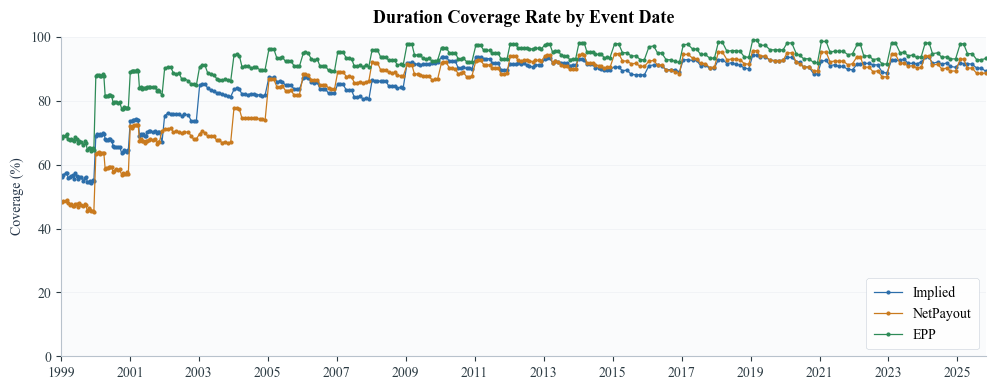

In [30]:
# Coverage diagnostic: share of event-firm obs with a valid duration
# All three duration measures are annual → matched by year_pred = event_year - 1

cov_evt = df_evt[['event_date', 'date', 'firm_id', 'year_pred']].copy()
cov_evt['year_pred_int'] = pd.to_numeric(cov_evt['year_pred'], errors='coerce')

# Implied coverage
imp_yr = df_imp[['firm_id', 'year', 'implied_duration']].copy()
imp_yr['year'] = pd.to_numeric(imp_yr['year'], errors='coerce')
cov_evt = cov_evt.merge(
    imp_yr.rename(columns={'implied_duration': 'Duration_Implied'}),
    left_on=['firm_id', 'year_pred_int'], right_on=['firm_id', 'year'], how='left',
).drop(columns=['year'], errors='ignore')

# NetPayout coverage
np_dur_col_cov = first_existing(
    df_np, ['Duration_NetPayout', 'Duration_NP', 'Duration_NetPayout_trim', 'Duration_NP_trim'],
    required=False, label='NetPayout duration for coverage')
if np_dur_col_cov:
    np_yr = df_np[['firm_id', 'year', np_dur_col_cov]].copy()
    np_yr['year'] = pd.to_numeric(np_yr['year'], errors='coerce')
    np_yr = np_yr.rename(columns={np_dur_col_cov: 'Duration_NetPayout'})
    cov_evt = cov_evt.merge(
        np_yr[['firm_id', 'year', 'Duration_NetPayout']],
        left_on=['firm_id', 'year_pred_int'], right_on=['firm_id', 'year'], how='left',
    ).drop(columns=['year'], errors='ignore')
else:
    cov_evt['Duration_NetPayout'] = np.nan

# EPP_w coverage (from Robustness parquet)
if 'EPP_w' in df_rob.columns:
    epp_yr = df_rob[['firm_id', 'year', 'EPP_w']].copy()
    epp_yr['year'] = pd.to_numeric(epp_yr['year'], errors='coerce').astype('Int64')
    cov_evt = cov_evt.merge(
        epp_yr.rename(columns={'year': 'year_pred_int2', 'EPP_w': 'EPP'}),
        left_on=['firm_id', 'year_pred_int'], right_on=['firm_id', 'year_pred_int2'], how='left',
    ).drop(columns=['year_pred_int2'], errors='ignore')
else:
    cov_evt['EPP'] = np.nan

# Overall coverage summary
_n = len(cov_evt)
cov_summary = pd.DataFrame({
    'Duration': ['Duration_Implied', 'Duration_NetPayout', 'EPP'],
    'N covered': [int(cov_evt['Duration_Implied'].notna().sum()),
                  int(cov_evt['Duration_NetPayout'].notna().sum()),
                  int(cov_evt['EPP'].notna().sum())],
    'N total': [_n, _n, _n],
    'Coverage %': [100 * cov_evt['Duration_Implied'].notna().mean(),
                   100 * cov_evt['Duration_NetPayout'].notna().mean(),
                   100 * cov_evt['EPP'].notna().mean()],
})
display(cov_summary.round(1))

# Coverage by year (cross-tabulation for detecting systematic gaps)
print("\nCoverage by prediction year:")
_cov_by_year = (
    cov_evt.assign(_y=lambda d: pd.to_numeric(d['year_pred'], errors='coerce'))
    .groupby('_y', as_index=True)
    .agg(N=('firm_id', 'count'),
         N_Implied=('Duration_Implied', lambda s: s.notna().sum()),
         N_NetPayout=('Duration_NetPayout', lambda s: s.notna().sum()),
         N_EPP=('EPP', lambda s: s.notna().sum()))
    .assign(pct_Implied=lambda d: (100 * d['N_Implied'] / d['N']).round(1),
            pct_NetPayout=lambda d: (100 * d['N_NetPayout'] / d['N']).round(1),
            pct_EPP=lambda d: (100 * d['N_EPP'] / d['N']).round(1))
)
display(_cov_by_year)

# Coverage by event date (plot)
cov_by_event = (
    cov_evt.groupby('event_date', as_index=False)[['Duration_Implied', 'Duration_NetPayout', 'EPP']]
    .agg(lambda s: s.notna().mean())
    .sort_values('event_date').dropna(subset=['event_date'])
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cov_by_event['event_date'], cov_by_event['Duration_Implied'] * 100,
        marker='o', markersize=2.0, linewidth=0.9, label='Implied', color=COLORS['blue'])
ax.plot(cov_by_event['event_date'], cov_by_event['Duration_NetPayout'] * 100,
        marker='o', markersize=2.0, linewidth=0.9, label='NetPayout', color=COLORS['orange'])
ax.plot(cov_by_event['event_date'], cov_by_event['EPP'] * 100,
        marker='o', markersize=2.0, linewidth=0.9, label='EPP',
        color=COLORS.get('green', '#2ca02c'))
ax.set_title('Duration Coverage Rate by Event Date')
ax.set_ylabel('Coverage (%)')
ax.set_ylim(0, 100)
style_axes(ax, grid_axis='y', grid_alpha=0.25)
style_time_axis(ax, x_min=cov_by_event['event_date'].min(),
                x_max=cov_by_event['event_date'].max(),
                x_ticks=cov_by_event['event_date'], date_fmt='%Y')
style_legend(ax, loc='lower right')
plt.tight_layout()
fig.savefig(GRAPH_DIR / 'duration_coverage_by_event.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Define key variables

In [31]:
# ── Implied duration: annual firm-year panel → merge by firm_id + year_pred ──
_imp_rob_cols = [c for c in df_imp.columns if c.startswith('dur_')]
imp_feat = df_imp[['firm_id', 'year', 'implied_duration'] + _imp_rob_cols].copy()
imp_feat['year'] = pd.to_numeric(imp_feat['year'], errors='coerce')
imp_feat['Duration_Implied'] = pd.to_numeric(imp_feat['implied_duration'], errors='coerce')
_imp_rename = {c: f'Duration_Implied_{c[4:]}' for c in _imp_rob_cols}
imp_feat = imp_feat.rename(columns=_imp_rename)
_imp_variant_cols = list(_imp_rename.values())
imp_feat = imp_feat[['firm_id', 'year', 'Duration_Implied'] + _imp_variant_cols].dropna(subset=['Duration_Implied']).copy()

df_evt['_year_pred_int'] = pd.to_numeric(df_evt['year_pred'], errors='coerce')
df_evt = df_evt.merge(imp_feat, left_on=['firm_id', '_year_pred_int'],
                      right_on=['firm_id', 'year'], how='left').drop(columns=['year', '_year_pred_int'], errors='ignore')
print(f"Implied: {['Duration_Implied'] + _imp_variant_cols}")

# ── NetPayout duration: annual firm-year merge ────────────────────────────────
np_dur_col = first_existing(
    df_np, ['Duration_NetPayout', 'Duration_NP', 'Duration_NetPayout_trim', 'Duration_NP_trim'],
    required=True, label='NetPayout duration')
np_feat = df_np[['firm_id', 'year', np_dur_col]].copy()
np_feat['year'] = pd.to_numeric(np_feat['year'], errors='coerce')
np_feat['Duration_NetPayout'] = pd.to_numeric(np_feat[np_dur_col], errors='coerce')
np_feat = np_feat[['firm_id', 'year', 'Duration_NetPayout']].dropna(subset=['Duration_NetPayout']).copy()

df_evt['_year_pred_int'] = pd.to_numeric(df_evt['year_pred'], errors='coerce')
df_evt = df_evt.merge(np_feat, left_on=['firm_id', '_year_pred_int'],
                      right_on=['firm_id', 'year'], how='left').drop(columns=['year', '_year_pred_int'], errors='ignore')
print("NetPayout: Duration_NetPayout")

# ── Robustness durations: EPP, SY_gross, SY_div_only, BM, EP ─────────────────
rob_cols_raw = ['SY_gross_w', 'SY_div_only_w', 'BM_w', 'EP_w', 'EPP_w']
rob_cols_avail = [c for c in rob_cols_raw if c in df_rob.columns]

rob_feat = df_rob[['firm_id', 'year'] + rob_cols_avail].copy()
rob_feat['year'] = pd.to_numeric(rob_feat['year'], errors='coerce').astype('Int64')

df_evt = (
    df_evt.merge(
        rob_feat.rename(columns={'year': 'year_pred'}),
        on=['firm_id', 'year_pred'],
        how='left',
    )
)
print(f"Robustness columns merged: {rob_cols_avail}")
if 'EPP_w' in df_evt.columns:
    print(f"EPP_w non-null: {df_evt['EPP_w'].notna().sum()}")

# ── Controls ──────────────────────────────────────────────────────────────────
if 'mcap_eur' in df_evt.columns:
    df_evt['log_mcap'] = np.log(pd.to_numeric(df_evt['mcap_eur'], errors='coerce').clip(lower=1.0))
    print(f"log_mcap computed from mcap_eur ({df_evt['log_mcap'].notna().mean():.1%} coverage)")
else:
    print("WARNING: mcap_eur not found — log_mcap unavailable")

lev_col = first_existing(df_np, ['leverage', 'lev'], required=False, label='leverage')
if lev_col:
    lev_feat = df_np[['firm_id', 'year', lev_col]].copy()
    lev_feat['year'] = pd.to_numeric(lev_feat['year'], errors='coerce')
    lev_feat['leverage'] = pd.to_numeric(lev_feat[lev_col], errors='coerce')
    lev_feat = lev_feat[['firm_id', 'year', 'leverage']].dropna(subset=['leverage']).copy()
    df_evt['_year_pred_int'] = pd.to_numeric(df_evt['year_pred'], errors='coerce')
    df_evt = df_evt.merge(lev_feat, left_on=['firm_id', '_year_pred_int'],
                          right_on=['firm_id', 'year'], how='left').drop(columns=['year', '_year_pred_int'], errors='ignore')
    print(f"leverage merged (col: {lev_col}, {df_evt['leverage'].notna().mean():.1%} coverage)")

# ── Book-to-Market (bm) ───────────────────────────────────────────────────────
if 'bm' not in df_evt.columns:
    bm_col = first_existing(df_np, ['bm'], required=False, label='bm')
    if bm_col:
        bm_feat = (df_np[['firm_id', 'year', bm_col]].copy()
                   .assign(year=lambda d: pd.to_numeric(d['year'], errors='coerce'),
                           bm=lambda d: pd.to_numeric(d[bm_col], errors='coerce'))
                   [['firm_id', 'year', 'bm']].dropna(subset=['bm']))
        df_evt['_yp'] = pd.to_numeric(df_evt['year_pred'], errors='coerce')
        df_evt = (df_evt.merge(bm_feat, left_on=['firm_id', '_yp'],
                               right_on=['firm_id', 'year'], how='left')
                        .drop(columns=['year', '_yp'], errors='ignore'))
        print(f"bm merged: {df_evt['bm'].notna().mean():.1%} coverage")
    else:
        print("bm not found in df_np — bm_std will be unavailable")

print(f"\ndf_evt shape: {df_evt.shape}")

Implied: ['Duration_Implied', 'Duration_Implied_A_CAPM_r_raw', 'Duration_Implied_A_CAPM_r', 'Duration_Implied_B_dss_approx', 'Duration_Implied_C_rho_roe_hi', 'Duration_Implied_C_rho_roe_lo', 'Duration_Implied_D_rho_g_hi', 'Duration_Implied_D_rho_g_lo', 'Duration_Implied_E_gbar_emp', 'Duration_Implied_E_gbar_eu_35', 'Duration_Implied_E_gbar_eu_45', 'Duration_Implied_F_beg_fallback', 'Duration_Implied_H_tight_winsor']
NetPayout: Duration_NetPayout
Robustness columns merged: ['SY_gross_w', 'SY_div_only_w', 'BM_w', 'EP_w', 'EPP_w']
EPP_w non-null: 117160
log_mcap computed from mcap_eur (98.2% coverage)
leverage merged (col: lev, 92.1% coverage)
bm merged: 92.6% coverage

df_evt shape: (129510, 46)


## 4. Standardize variables

In [32]:
def zscore_by_year(df, col, year_col='year_pred'):
    # Sample standard deviation (ddof=1) is the standard in econometrics.
    # ddof=0 (population std) underestimates variance in small cross-sections.
    def _z(s):
        s = pd.to_numeric(s, errors='coerce')
        mu = s.mean(skipna=True)
        sd = s.std(skipna=True, ddof=1)   # ddof=1: sample std
        if pd.isna(sd) or sd == 0:
            return pd.Series(np.nan, index=s.index)
        return (s - mu) / sd
    return df.groupby(year_col, dropna=False)[col].transform(_z)

std_map = {
    'Duration_Implied':    'Duration_Implied_std',
    'Duration_NetPayout':  'Duration_NetPayout_std',
    'EPP_w':               'EPP_std',
    'SY_gross_w':          'SY_gross_std',
    'SY_div_only_w':       'SY_div_only_std',
    'BM_w':                'BM_rob_std',
    'EP_w':                'EP_rob_std',
    'beta':                'beta_std',
    'log_mcap':            'log_mcap_std',
    'leverage':            'leverage_std',
    'bm':                  'bm_std',
}

# Auto-add all implied duration robustness variants
for vc in [c for c in df_evt.columns if c.startswith('Duration_Implied_') and not c.endswith('_std')]:
    std_map[vc] = vc + '_std'

for raw_col, std_col in std_map.items():
    if raw_col in df_evt.columns:
        df_evt[std_col] = zscore_by_year(df_evt, raw_col, year_col='year_pred')

std_cols_present = [c for c in std_map.values() if c in df_evt.columns]

# Standardization diagnostic: mean should be ≈0, std should be ≈1
print("Standardization diagnostic (mean ≈ 0, std ≈ 1):")
_diag = df_evt[std_cols_present].describe().T[['mean', 'std', 'count']].copy()
_diag['missing_pct'] = ((len(df_evt) - _diag['count']) / len(df_evt) * 100).round(1)
_diag['flag_mean'] = (_diag['mean'].abs() > 0.01).map({True: 'WARN', False: 'ok'})
_diag['flag_std']  = (~_diag['std'].between(0.95, 1.05)).map({True: 'WARN', False: 'ok'})
display(_diag.round(4))

_flagged = _diag[(_diag['flag_mean'] == 'WARN') | (_diag['flag_std'] == 'WARN')]
if not _flagged.empty:
    print("WARNING: Unexpected mean/std in:", list(_flagged.index))
else:
    print("All standardized columns pass diagnostic checks.")

Standardization diagnostic (mean ≈ 0, std ≈ 1):


,mean,std,count,missing_pct,flag_mean,flag_std
Duration_Implied_std,-0.0,0.9999,107885.0,16.7,ok,ok
Duration_NetPayout_std,-0.0,0.9999,105293.0,18.7,ok,ok
EPP_std,-0.0,0.9999,117160.0,9.5,ok,ok
SY_gross_std,-0.0,0.9999,110766.0,14.5,ok,ok
SY_div_only_std,-0.0,0.9999,102227.0,21.1,ok,ok
BM_rob_std,0.0,0.9999,119970.0,7.4,ok,ok
EP_rob_std,-0.0,0.9999,120824.0,6.7,ok,ok
beta_std,0.0,0.9999,123336.0,4.8,ok,ok
log_mcap_std,-0.0,0.9999,127185.0,1.8,ok,ok
leverage_std,-0.0,0.9999,119253.0,7.9,ok,ok


All standardized columns pass diagnostic checks.


## 5. Pre-Regression Diagnostics

Standard sanity checks before estimation:
- **[4a]** Shock statistics and orthogonality test (flag if |corr(MP, Info)| > 0.3)
- **[4b]** Median duration by year — checks for systematic coverage gaps
- **[4c]** Mean AR_0 by |ShockMP| quintile — monotonicity test
- **[4d]** Pairwise correlations in Model 4 sample — multicollinearity screening

In [33]:
print("=" * 60)
print("SECTION 5: PRE-REGRESSION DIAGNOSTICS")
print("=" * 60)

# ── 4a. Shock Statistics ──────────────────────────────────────────────────────
print("\n[4a] Shock Statistics (event-level, one row per event date)")
_evt_shocks = df_evt[['event_date', 'ShockMP', 'ShockInfo']].drop_duplicates('event_date').dropna()
print(_evt_shocks[['ShockMP', 'ShockInfo']].describe().T.round(4).to_string())

_corr_mp_info = _evt_shocks['ShockMP'].corr(_evt_shocks['ShockInfo'])
print(f"\nCorrelation ShockMP -- ShockInfo: {_corr_mp_info:.4f}")
if abs(_corr_mp_info) > 0.3:
    print(f"WARNING: |corr| = {abs(_corr_mp_info):.3f} > 0.3 -- "
          f"orthogonality assumption may be violated")
else:
    print("OK: |corr| <= 0.3 -- shock series appear sufficiently orthogonal")

_mp_std   = _evt_shocks['ShockMP'].std()
_info_std = _evt_shocks['ShockInfo'].std()
print(f"Events with |ShockMP| > 1sigma:   {(_evt_shocks['ShockMP'].abs() > _mp_std).sum()}")
print(f"Events with |ShockInfo| > 1sigma: {(_evt_shocks['ShockInfo'].abs() > _info_std).sum()}")

# ── 4b. Duration Distribution by Event Year ───────────────────────────────────
print("\n[4b] Median duration by prediction year (systematic missingness check)")
_dur_raw_cols = [c for c in ['Duration_Implied', 'Duration_NetPayout', 'EPP_w']
                 if c in df_evt.columns]
if _dur_raw_cols:
    display(df_evt.groupby(
        pd.to_numeric(df_evt['year_pred'], errors='coerce'))[_dur_raw_cols].median().round(2))

# ── 4c. Return Distribution by |ShockMP| Quintile ────────────────────────────
print("\n[4c] Mean |AR_0| by |ShockMP| quintile (monotonicity check)")
_ret_diag = df_evt[['event_date', 'AR_0', 'ShockMP']].dropna().copy()
_shock_q  = (
    _ret_diag[['event_date', 'ShockMP']].drop_duplicates('event_date')
    .assign(abs_shock=lambda d: d['ShockMP'].abs())
    .assign(shock_quintile=lambda d: pd.qcut(d['abs_shock'], q=5, labels=[1, 2, 3, 4, 5]))
)
_ret_diag = _ret_diag.merge(_shock_q[['event_date', 'shock_quintile']], on='event_date', how='left')
_ar_by_q  = (
    _ret_diag.groupby('shock_quintile')[['AR_0']]
    .agg(mean_AR_0=('AR_0', 'mean'), std_AR_0=('AR_0', 'std'), N=('AR_0', 'count'))
    .reset_index()
)
display(_ar_by_q.round(4))
_is_monotone = (_ar_by_q['mean_AR_0'].abs().is_monotonic_increasing or
                _ar_by_q['mean_AR_0'].abs().is_monotonic_decreasing)
if not _is_monotone:
    print("NOTE: |AR_0| is not strictly monotonic in |ShockMP| quintiles "
          "(common in smaller cells; not necessarily indicative of an error)")

# ── 4d. Multicollinearity Check (Model 4 sample) ─────────────────────────────
print("\n[4d] Pairwise correlations in Model 4 sample (multicollinearity check)")
_mc_cols = [c for c in ['Duration_Implied_std', 'Duration_NetPayout_std', 'EPP_std',
                         'beta_std', 'log_mcap_std', 'leverage_std', 'bm_std']
            if c in df_evt.columns]
_mc_work = (df_evt[['AR_0', 'ShockMP', 'ShockInfo', 'event_date', 'firm_id'] + _mc_cols]
            .dropna(subset=['AR_0', 'ShockMP', 'ShockInfo']).dropna(subset=_mc_cols))
print(f"Model 4 full-sample size (all controls non-missing): {len(_mc_work):,} obs")

if len(_mc_cols) > 1:
    _corr_matrix = _mc_work[_mc_cols].corr().round(3)
    display(_corr_matrix)
    _high_corr = [(c1, c2, _corr_matrix.loc[c1, c2])
                  for i, c1 in enumerate(_mc_cols)
                  for c2 in _mc_cols[i+1:]
                  if abs(_corr_matrix.loc[c1, c2]) > 0.7]
    if _high_corr:
        print("WARNING: Potential multicollinearity (|corr| > 0.7):")
        for c1, c2, v in _high_corr:
            print(f"  {c1} -- {c2}: {v:.3f}")
    else:
        print("No pairwise correlation exceeds 0.7.")
    # Explicitly report duration-bm correlations (expected to be non-zero)
    for _dur_c in ['Duration_Implied_std', 'Duration_NetPayout_std', 'EPP_std']:
        if _dur_c in _mc_cols and 'bm_std' in _mc_cols:
            _dv = _corr_matrix.loc[_dur_c, 'bm_std']
            print(f"Note: corr({_dur_c}, bm_std) = {_dv:.3f} "
                  f"(expected non-zero -- duration and B/M are conceptually related)")

SECTION 5: PRE-REGRESSION DIAGNOSTICS

[4a] Shock Statistics (event-level, one row per event date)
           count    mean     std     min     25%     50%     75%     max
ShockMP    312.0  0.0042  0.0331 -0.1425 -0.0089  0.0011  0.0158  0.1900
ShockInfo  312.0 -0.0011  0.0284 -0.1201 -0.0121 -0.0009  0.0100  0.1371

Correlation ShockMP -- ShockInfo: 0.0048
OK: |corr| <= 0.3 -- shock series appear sufficiently orthogonal
Events with |ShockMP| > 1sigma:   58
Events with |ShockInfo| > 1sigma: 65

[4b] Median duration by prediction year (systematic missingness check)


,Duration_Implied,Duration_NetPayout,EPP_w
year_pred,,,
1998,16.76,19.81,26.23
1999,16.21,23.98,28.06
2000,16.76,23.35,27.44
2001,16.58,23.69,22.37
2002,16.29,23.10,18.20
2003,14.64,24.05,20.29
2004,15.56,24.26,23.25
2005,15.77,24.48,27.69
2006,16.48,25.00,31.00



[4c] Mean |AR_0| by |ShockMP| quintile (monotonicity check)


/var/folders/r2/vtz74sz14fx185wt9m3c781w0000gn/T/ipykernel_68562/2426397354.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _ret_diag.groupby('shock_quintile')[['AR_0']]


,shock_quintile,mean_AR_0,std_AR_0,N
0,1,0.0003,0.0238,26135
1,2,0.0002,0.0226,25792
2,3,0.0006,0.0209,25699
3,4,-0.0008,0.0246,25610
4,5,0.0003,0.025,26274


NOTE: |AR_0| is not strictly monotonic in |ShockMP| quintiles (common in smaller cells; not necessarily indicative of an error)

[4d] Pairwise correlations in Model 4 sample (multicollinearity check)
Model 4 full-sample size (all controls non-missing): 96,968 obs


,Duration_Implied_std,Duration_NetPayout_std,EPP_std,beta_std,log_mcap_std,leverage_std,bm_std
Duration_Implied_std,1.000,0.390,0.384,-0.024,0.078,-0.308,-0.509
Duration_NetPayout_std,0.390,1.000,0.401,-0.063,0.140,0.037,-0.445
EPP_std,0.384,0.401,1.000,-0.034,0.137,-0.476,-0.857
beta_std,-0.024,-0.063,-0.034,1.000,0.015,0.104,0.086
log_mcap_std,0.078,0.140,0.137,0.015,1.000,-0.059,-0.197
leverage_std,-0.308,0.037,-0.476,0.104,-0.059,1.000,0.585
bm_std,-0.509,-0.445,-0.857,0.086,-0.197,0.585,1.000


  EPP_std -- bm_std: -0.857
Note: corr(Duration_Implied_std, bm_std) = -0.509 (expected non-zero -- duration and B/M are conceptually related)
Note: corr(Duration_NetPayout_std, bm_std) = -0.445 (expected non-zero -- duration and B/M are conceptually related)
Note: corr(EPP_std, bm_std) = -0.857 (expected non-zero -- duration and B/M are conceptually related)


## 6. Define regression helper functions

In [34]:
def build_formula(depvar, duration_var, include_event_fe=False, include_raw_shocks=False,
                  controls=None, include_bm=False):
    """
    Build OLS formula string and term list.

    IMPORTANT: Formula is 'depvar ~ rhs' (with intercept), NOT '~ 0 + rhs'.
    Suppressing the intercept (0 +) forces the unconditional mean of the LHS to zero,
    which biases all coefficients in any specification without Event FE (Models 1-3, 5).
    Model 4 with C(event_date) is unaffected (event dummies span the intercept),
    but consistency requires the same convention across all models.

    Raw shock levels (ShockMP, ShockInfo):
      - ALWAYS included when include_event_fe=False: absorb the average price impact
        of the shock unrelated to duration (omitting them would bias the interaction coef)
      - NEVER included when include_event_fe=True: C(event_date) absorbs them exactly

    BM interactions (include_bm=True):
      - Only for Model 4 (Event FE). Omitting from non-FE specs avoids collinearity
        between duration and bm which is large without within-event variation.
    """
    controls = controls or []
    terms = [
        f'ShockMP:{duration_var}',
        f'ShockInfo:{duration_var}',
    ]
    if 'beta' in controls:
        terms += ['ShockMP:beta_std', 'ShockInfo:beta_std']
    if 'size' in controls:
        terms += ['ShockMP:log_mcap_std', 'ShockInfo:log_mcap_std']
    if 'leverage' in controls:
        terms += ['ShockMP:leverage_std', 'ShockInfo:leverage_std']
    if include_bm:
        terms += ['ShockMP:bm_std', 'ShockInfo:bm_std']
    # Raw shock levels: included when no Event FE (they absorb average shock effect)
    if include_raw_shocks:
        terms += ['ShockMP', 'ShockInfo']
    if include_event_fe:
        terms += ['C(event_date)']
    rhs = ' + '.join(terms)
    # Intercept always present — no '0 +' prefix
    return f'{depvar} ~ {rhs}', terms


def _safe_get(series, key):
    return float(series[key]) if key in series.index else np.nan

def _cluster_groups(df, cluster='event'):
    if cluster == 'twoway' and 'firm_id' in df.columns:
        return np.column_stack([pd.Categorical(df['event_date']).codes,
                                pd.Categorical(df['firm_id']).codes])
    return pd.Categorical(df['event_date']).codes

def _clean_controls_label(controls):
    if not controls:
        return 'None'
    label_map = {'beta': 'beta', 'size': 'size', 'leverage': 'leverage', 'bm': 'bm'}
    return ', '.join(label_map[c] for c in controls if c in label_map)

def _sig_stars(p):
    if pd.isna(p):  return ''
    if p < 0.01:    return '***'
    if p < 0.05:    return '**'
    if p < 0.10:    return '*'
    return ''

def _coef_term(shock_name, duration_var):
    return f'{shock_name}:{duration_var}'

def run_regression(df, depvar, duration_var, specification_name,
                   include_event_fe=False, include_raw_shocks=False,
                   controls=None, cluster='event', include_bm=False):
    controls = controls or []
    formula, terms = build_formula(
        depvar=depvar, duration_var=duration_var,
        include_event_fe=include_event_fe, include_raw_shocks=include_raw_shocks,
        controls=controls, include_bm=include_bm)

    needed = [depvar, 'ShockMP', 'ShockInfo', duration_var, 'event_date', 'firm_id']
    if 'beta'     in controls: needed.append('beta_std')
    if 'size'     in controls: needed.append('log_mcap_std')
    if 'leverage' in controls: needed.append('leverage_std')
    if include_bm:             needed.append('bm_std')

    work = df[[c for c in needed if c in df.columns]].dropna().copy()
    if work.empty:
        return None

    model  = smf.ols(formula=formula, data=work)
    groups = _cluster_groups(work, cluster=cluster)
    res    = model.fit(cov_type='cluster', cov_kwds={'groups': groups})

    # Safety check: warn if cluster count is below rule-of-thumb threshold
    n_clusters = int(work['event_date'].nunique())
    if n_clusters < 30:
        print(f"WARNING: {n_clusters} clusters in '{specification_name}' "
              f"({duration_var}) — clustered SEs unreliable (rule of thumb: ≥30).")

    mp_term   = _coef_term('ShockMP',   duration_var)
    info_term = _coef_term('ShockInfo', duration_var)

    row = {
        'depvar':             depvar,
        'duration_name':      duration_var,
        'specification_name': specification_name,
        'event_FE':           'Yes' if include_event_fe else 'No',
        'controls':           _clean_controls_label(controls),
        'coef_mp_duration':   _safe_get(res.params,  mp_term),
        'se_mp_duration':     _safe_get(res.bse,     mp_term),
        't_mp_duration':      _safe_get(res.tvalues, mp_term),
        'p_mp_duration':      _safe_get(res.pvalues, mp_term),
        'coef_info_duration': _safe_get(res.params,  info_term),
        'se_info_duration':   _safe_get(res.bse,     info_term),
        't_info_duration':    _safe_get(res.tvalues, info_term),
        'p_info_duration':    _safe_get(res.pvalues, info_term),
        'coef_mp_beta':       _safe_get(res.params, 'ShockMP:beta_std'),
        'coef_info_beta':     _safe_get(res.params, 'ShockInfo:beta_std'),
        'coef_mp_size':       _safe_get(res.params, 'ShockMP:log_mcap_std'),
        'coef_info_size':     _safe_get(res.params, 'ShockInfo:log_mcap_std'),
        'coef_mp_leverage':   _safe_get(res.params, 'ShockMP:leverage_std'),
        'coef_info_leverage': _safe_get(res.params, 'ShockInfo:leverage_std'),
        'N':                  int(res.nobs),
        'n_events':           int(work['event_date'].nunique()),
        'n_clusters':         n_clusters,
        'r_squared':          float(res.rsquared)     if hasattr(res, 'rsquared')     else np.nan,
        'r_squared_adj':      float(res.rsquared_adj) if hasattr(res, 'rsquared_adj') else np.nan,
        'model_obj':          res,
    }
    return row

def make_reader_entry(coef, t_stat, p):
    if pd.isna(coef):
        return ''
    return f'{coef:.4f}{_sig_stars(p)} ({t_stat:.2f})'

## 7. Estimate main models

In [35]:
print("=" * 60)
print("SECTION 7: MAIN REGRESSION MODELS")
print("=" * 60)

depvars_main = [c for c in ['AR_0', 'AR_0_1'] if c in df_evt.columns]

# Include EPP_std (robustness) as third duration measure if available
duration_vars = [c for c in
    ['Duration_Implied_std', 'Duration_NetPayout_std', 'EPP_std',
     'SY_gross_std', 'SY_div_only_std', 'BM_rob_std', 'EP_rob_std']
    if c in df_evt.columns]
print(f"Duration variables: {duration_vars}")

controls_available = {
    'beta':     'beta_std'     in df_evt.columns,
    'size':     'log_mcap_std' in df_evt.columns,
    'leverage': 'leverage_std' in df_evt.columns,
    'bm':       'bm_std'       in df_evt.columns,
}

ctrl_beta = [c for c in ['beta']                    if controls_available.get(c)]
ctrl_plus = [c for c in ['beta', 'size', 'leverage'] if controls_available.get(c)]

# Model 1: AR ~ intercept + ShockMP:D + ShockInfo:D + ShockMP + ShockInfo
# Model 2: + ShockMP:beta + ShockInfo:beta
# Model 3: + ShockMP:size + ShockInfo:size + ShockMP:lev + ShockInfo:lev
# Model 4: + ShockMP:bm + ShockInfo:bm + C(event_date) [no raw shock levels — absorbed by FE]
# Model 5: no FE, full controls + raw shock levels

spec_grid = [
    {'name': 'Model 1: Baseline',
     'event_fe': False, 'raw_shocks': True,  'controls': [],        'bm': False},
    {'name': 'Model 2: + beta',
     'event_fe': False, 'raw_shocks': True,  'controls': ctrl_beta, 'bm': False},
    {'name': 'Model 3: + size/leverage',
     'event_fe': False, 'raw_shocks': True,  'controls': ctrl_plus, 'bm': False},
    {'name': 'Model 4: Event FE + all controls',
     'event_fe': True,  'raw_shocks': False, 'controls': ctrl_plus, 'bm': True},
    {'name': 'Model 5: No Event FE + raw shocks',
     'event_fe': False, 'raw_shocks': True,  'controls': ctrl_plus, 'bm': False},
]

results = []
for dep in depvars_main:
    for dur in duration_vars:
        for spec in spec_grid:
            row = run_regression(
                df=df_evt, depvar=dep, duration_var=dur,
                specification_name=spec['name'],
                include_event_fe=spec['event_fe'],
                include_raw_shocks=spec['raw_shocks'],
                controls=spec['controls'],
                cluster='event',
                include_bm=spec.get('bm', False),
            )
            if row is not None:
                results.append(row)

df_results = pd.DataFrame(results)
if df_results.empty:
    raise ValueError('No models estimated. Check data availability and variable merges.')

display(df_results[['depvar', 'duration_name', 'specification_name',
                     'event_FE', 'controls', 'N', 'n_events', 'n_clusters',
                     'r_squared', 'r_squared_adj']])

SECTION 7: MAIN REGRESSION MODELS
Duration variables: ['Duration_Implied_std', 'Duration_NetPayout_std', 'EPP_std', 'SY_gross_std', 'SY_div_only_std', 'BM_rob_std', 'EP_rob_std']


,depvar,duration_name,specification_name,event_FE,controls,N,n_events,n_clusters,r_squared,r_squared_adj
0,AR_0,Duration_Implied_std,Model 1: Baseline,No,None,107885,312,312,0.016656,0.016620
1,AR_0,Duration_Implied_std,Model 2: + beta,No,beta,107493,312,312,0.022458,0.022404
2,AR_0,Duration_Implied_std,Model 3: + size/leverage,No,"beta, size, leverage",105297,312,312,0.026331,0.026239
3,AR_0,Duration_Implied_std,Model 4: Event FE + all controls,Yes,"beta, size, leverage",105297,312,312,0.087613,0.084823
4,AR_0,Duration_Implied_std,Model 5: No Event FE + raw shocks,No,"beta, size, leverage",105297,312,312,0.026331,0.026239
...,...,...,...,...,...,...,...,...,...,...
65,AR_0_1,EP_rob_std,Model 1: Baseline,No,None,119942,312,312,0.005440,0.005407
66,AR_0_1,EP_rob_std,Model 2: + beta,No,beta,116611,312,312,0.009042,0.008991
67,AR_0_1,EP_rob_std,Model 3: + size/leverage,No,"beta, size, leverage",114918,312,312,0.010714,0.010628
68,AR_0_1,EP_rob_std,Model 4: Event FE + all controls,Yes,"beta, size, leverage",114057,312,312,0.076361,0.073754


In [36]:
# ── Plot-style constants ─────────────────────────────────────────────────────
# Defined here (after regressions) so every downstream cell — robustness
# plots AND coefficient plots — can use them regardless of execution order.

dur_short = {
    'Duration_Implied_std':   'Implied',
    'Duration_NetPayout_std': 'NetPayout',
    'EPP_std':             'EPP',
}
dep_short = {'AR_0': 'AR(0)', 'AR_0_1': 'AR(0,+1)'}

_DUR_COLORS = {
    'Duration_Implied_std':   COLORS['blue'],
    'Duration_NetPayout_std': COLORS['accent'],
    'EPP_std':             COLORS.get('green', '#2ca02c'),
}
_DUR_MARKERS = {
    'Duration_Implied_std':   'o',
    'Duration_NetPayout_std': 's',
    'EPP_std':             '^',
}

# Convenience list: only duration vars actually present in df_evt
dur_list = [d for d in ['Duration_Implied_std', 'Duration_NetPayout_std', 'EPP_std',
                          'SY_gross_std', 'SY_div_only_std', 'BM_rob_std', 'EP_rob_std']
            if d in df_evt.columns]

print(f"Plot constants loaded.  dur_list = {dur_list}")

Plot constants loaded.  dur_list = ['Duration_Implied_std', 'Duration_NetPayout_std', 'EPP_std', 'SY_gross_std', 'SY_div_only_std', 'BM_rob_std', 'EP_rob_std']


## Chapter 8: Robustness Checks

### 8.1 Original Robustness Checks (Placebo, Two-Way Clustering, DSS Variants)

Standard robustness: pre-event placebo (AR_lag1), 3-day window (AR_m1_1), two-way clustering, and implied duration DSS specification variants.

In [37]:
print("=" * 60)
print("SECTION 8: ORIGINAL ROBUSTNESS MODELS")
print("=" * 60)

robust_rows = []

# ── Placebo 1: Pre-event day (AR_lag1) ───────────────────────────────────────
if 'AR_lag1' in df_evt.columns:
    for dur in duration_vars:
        row = run_regression(df=df_evt, depvar='AR_lag1', duration_var=dur,
                             specification_name='Placebo: Pre-event day (AR_lag1, Event FE)',
                             include_event_fe=True, include_raw_shocks=False,
                             controls=ctrl_plus, cluster='event', include_bm=True)
        if row is not None:
            robust_rows.append(row)
else:
    print('WARNING: AR_lag1 not found — pre-event placebo skipped.')

# ── Placebo 2: 3-day window AR_m1_1 ─────────────────────────────────────────
if 'AR_m1_1' in df_evt.columns:
    for dur in duration_vars:
        row = run_regression(df=df_evt, depvar='AR_m1_1', duration_var=dur,
                             specification_name='Robustness: 3-day window AR_m1_1 (Event FE)',
                             include_event_fe=True, include_raw_shocks=False,
                             controls=ctrl_plus, cluster='event', include_bm=True)
        if row is not None:
            robust_rows.append(row)

# ── Two-way clustering ────────────────────────────────────────────────────────
for dep in depvars_main:
    for dur in duration_vars:
        row = run_regression(df=df_evt, depvar=dep, duration_var=dur,
                             specification_name='Robustness: Model 4 two-way clustering',
                             include_event_fe=True, include_raw_shocks=False,
                             controls=ctrl_plus, cluster='twoway', include_bm=True)
        if row is not None:
            robust_rows.append(row)

# ── Implied Duration specification robustness (DSS variants) ──────────────────
_imp_variant_std_cols = sorted([
    c for c in df_evt.columns
    if c.startswith('Duration_Implied_') and c.endswith('_std')
])
print(f"\nDSS robustness variants: {len(_imp_variant_std_cols)} columns")
for var_col in _imp_variant_std_cols:
    for dep in depvars_main:
        row = run_regression(
            df=df_evt, depvar=dep, duration_var=var_col,
            specification_name=f'DSS Variant: {var_col.replace("Duration_Implied_","").replace("_std","")}',
            include_event_fe=True, include_raw_shocks=False,
            controls=ctrl_plus, cluster='event', include_bm=True)
        if row is not None:
            robust_rows.append(row)

df_robust = pd.DataFrame(robust_rows)
if not df_robust.empty:
    display(df_robust[['depvar', 'duration_name', 'specification_name', 'N', 'n_clusters',
                        'coef_mp_duration', 't_mp_duration', 'p_mp_duration',
                        'coef_info_duration', 't_info_duration', 'p_info_duration']])
    _dss = df_robust[df_robust['specification_name'].str.startswith('DSS Variant')]
    if not _dss.empty:
        print("\n── DSS Specification Robustness ──")
        display(_dss[['depvar', 'duration_name', 'N',
                       'coef_mp_duration', 't_mp_duration',
                       'coef_info_duration', 't_info_duration']].round(4))
else:
    print('No robustness models estimated.')

SECTION 8: ORIGINAL ROBUSTNESS MODELS


/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Code/.venv_thesis/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Code/.venv_thesis/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Code/.venv_thesis/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.diag(self.cov_params()))
/Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Code/.venv_thesis/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:1884: RuntimeWarning:


DSS robustness variants: 13 columns


,depvar,duration_name,specification_name,N,n_clusters,coef_mp_duration,t_mp_duration,p_mp_duration,coef_info_duration,t_info_duration,p_info_duration
0,AR_lag1,Duration_Implied_std,"Placebo: Pre-event day (AR_lag1, Event FE)",105007,312,0.000272,0.077766,0.938014,0.003533,0.786424,0.431619
1,AR_lag1,Duration_NetPayout_std,"Placebo: Pre-event day (AR_lag1, Event FE)",102950,312,0.007640,2.119682,0.034033,0.006982,1.288746,0.197486
2,AR_lag1,EPP_std,"Placebo: Pre-event day (AR_lag1, Event FE)",112060,312,0.000757,0.114691,0.908690,0.015358,2.221148,0.026341
3,AR_lag1,SY_gross_std,"Placebo: Pre-event day (AR_lag1, Event FE)",105929,312,-0.002785,-0.712255,0.476307,0.000827,0.203280,0.838916
4,AR_lag1,SY_div_only_std,"Placebo: Pre-event day (AR_lag1, Event FE)",98441,312,-0.003460,-1.181460,0.237420,-0.004626,-1.260454,0.207506
5,AR_lag1,BM_rob_std,"Placebo: Pre-event day (AR_lag1, Event FE)",114739,312,0.008401,1.168222,0.242717,0.003808,0.498644,0.618030
6,AR_lag1,EP_rob_std,"Placebo: Pre-event day (AR_lag1, Event FE)",114457,312,0.000073,0.024915,0.980122,-0.003516,-0.706765,0.479712
7,AR_m1_1,Duration_Implied_std,Robustness: 3-day window AR_m1_1 (Event FE),104338,312,-0.000581,-0.093613,0.925417,-0.000255,-0.028956,0.976899
8,AR_m1_1,Duration_NetPayout_std,Robustness: 3-day window AR_m1_1 (Event FE),102321,312,-0.000334,-0.065563,0.947726,0.005349,0.652361,0.514168
9,AR_m1_1,EPP_std,Robustness: 3-day window AR_m1_1 (Event FE),111323,312,0.000294,0.027488,0.978070,0.026075,1.944290,0.051861



── DSS Specification Robustness ──


,depvar,duration_name,N,coef_mp_duration,t_mp_duration,coef_info_duration,t_info_duration
28,AR_0,Duration_Implied_A_CAPM_r_raw_std,105297,0.0001,0.0140,-0.0057,-1.1272
29,AR_0_1,Duration_Implied_A_CAPM_r_raw_std,104628,-0.0064,-1.0445,-0.0082,-1.3649
30,AR_0,Duration_Implied_A_CAPM_r_std,105297,-0.0010,-0.2288,-0.0065,-1.4032
31,AR_0_1,Duration_Implied_A_CAPM_r_std,104628,-0.0055,-0.9105,-0.0075,-1.2908
32,AR_0,Duration_Implied_B_dss_approx_std,105297,-0.0015,-0.2979,0.0013,0.3184
33,AR_0_1,Duration_Implied_B_dss_approx_std,104628,-0.0009,-0.1227,-0.0038,-0.5810
34,AR_0,Duration_Implied_C_rho_roe_hi_std,105297,-0.0022,-0.5148,0.0016,0.4246
35,AR_0_1,Duration_Implied_C_rho_roe_hi_std,104628,-0.0015,-0.2570,-0.0046,-0.8090
36,AR_0,Duration_Implied_C_rho_roe_lo_std,105297,-0.0010,-0.1642,0.0026,0.5244
37,AR_0_1,Duration_Implied_C_rho_roe_lo_std,104628,0.0001,0.0156,-0.0021,-0.2477


### 8.2 Shock Magnitude Terciles

Tests whether the duration-return relationship is monotone in shock magnitude, as theory predicts.

In [38]:
print("=" * 60)
print("SECTION 8.2: SHOCK MAGNITUDE TERCILES")
print("=" * 60)

new_robust_rows = []

# ── [5a] |ShockMP| tercile subsamples ───────────────────────────────────────
print("\n[5a] |ShockMP| tercile subsamples (Model 4)")
_shock_tercile = (
    df_evt[['event_date', 'ShockMP']].drop_duplicates('event_date').copy()
    .assign(abs_shock=lambda d: d['ShockMP'].abs())
    .assign(shock_tercile=lambda d: pd.qcut(d['abs_shock'], q=3,
                                             labels=['Low', 'Med', 'High']))
)
df_evt = df_evt.merge(_shock_tercile[['event_date', 'shock_tercile']],
                      on='event_date', how='left')

for _tercile in ['Low', 'Med', 'High']:
    _df_sub = df_evt[df_evt['shock_tercile'] == _tercile].copy()
    for _dur in duration_vars:
        _row = run_regression(
            df=_df_sub, depvar='AR_0', duration_var=_dur,
            specification_name=f'Robustness: Model 4 |ShockMP| tercile={_tercile}',
            include_event_fe=True, include_raw_shocks=False,
            controls=ctrl_plus, cluster='event', include_bm=True)
        if _row is not None:
            _row['subsample'] = f'|ShockMP| tercile: {_tercile}'
            new_robust_rows.append(_row)

# Summary table
_5a_df = pd.DataFrame([r for r in new_robust_rows
                        if '|ShockMP| tercile' in r.get('subsample', '')])
if not _5a_df.empty:
    _5a_show = _5a_df[[
        'subsample', 'duration_name', 'N', 'n_events', 'n_clusters',
        'coef_mp_duration', 't_mp_duration', 'p_mp_duration',
        'coef_info_duration', 't_info_duration', 'p_info_duration']].copy()
    print("\nShock Magnitude Terciles — Model 4 Summary:")
    print(_5a_show.round(4).to_string(index=False))


SECTION 8.2: SHOCK MAGNITUDE TERCILES

[5a] |ShockMP| tercile subsamples (Model 4)

Shock Magnitude Terciles — Model 4 Summary:
              subsample          duration_name     N  n_events  n_clusters  coef_mp_duration  t_mp_duration  p_mp_duration  coef_info_duration  t_info_duration  p_info_duration
 |ShockMP| tercile: Low   Duration_Implied_std 33935       104         104            0.0614         1.5607         0.1186              0.0034           0.2755           0.7829
 |ShockMP| tercile: Low Duration_NetPayout_std 32943       104         104           -0.0129        -0.2314         0.8170              0.0222           1.4890           0.1365
 |ShockMP| tercile: Low                EPP_std 36486       104         104            0.0080         0.0863         0.9312              0.0179           1.0035           0.3156
 |ShockMP| tercile: Low           SY_gross_std 34178       104         104           -0.0042        -0.1125         0.9104             -0.0046          -0.7342     

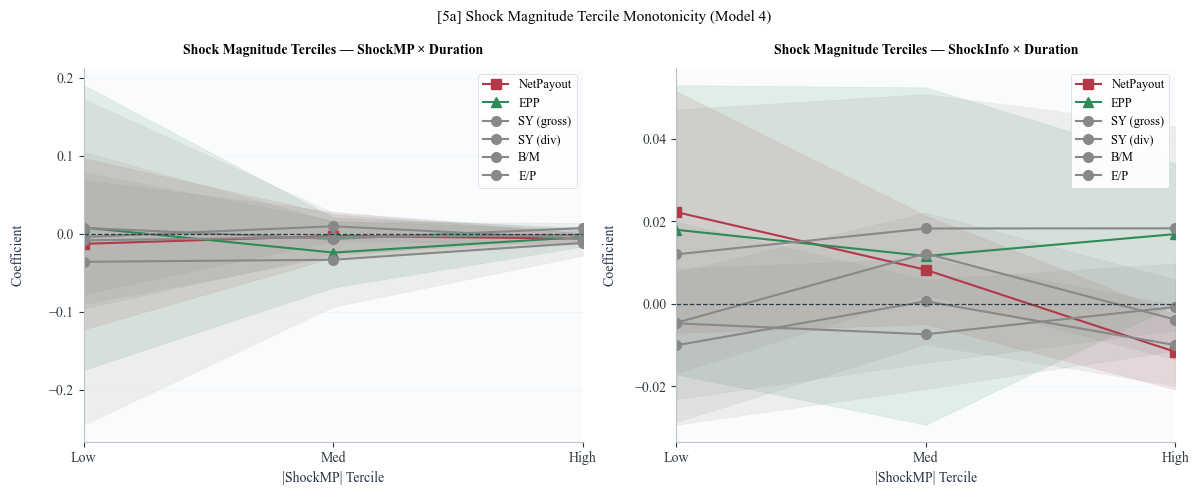

In [39]:
# Plot [5a]: Shock magnitude tercile monotonicity
# Duration_Implied is consistently insignificant — omitted from robustness plots
_PLOT_DURS = [d for d in ['Duration_NetPayout_std', 'EPP_std', 'SY_gross_std', 'SY_div_only_std', 'BM_rob_std', 'EP_rob_std'] if d in duration_vars]
_dur_short_rob = {
    'Duration_NetPayout_std': 'NetPayout',
    'EPP_std':                'EPP',
    'SY_gross_std':           'SY (gross)',
    'SY_div_only_std':        'SY (div)',
    'BM_rob_std':             'B/M',
    'EP_rob_std':             'E/P',
}

_5a_df = pd.DataFrame([r for r in new_robust_rows
                        if '|ShockMP| tercile' in r.get('subsample', '')])
if not _5a_df.empty:
    _tercile_order = ['Low', 'Med', 'High']
    _x_t = np.arange(3)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for _ax, _coef_col, _se_col, _shock_lbl in [
        (axes[0], 'coef_mp_duration',   'se_mp_duration',   'ShockMP × Duration'),
        (axes[1], 'coef_info_duration', 'se_info_duration', 'ShockInfo × Duration'),
    ]:
        for _dur in _PLOT_DURS:
            _ys, _se_vals = [], []
            for _t in _tercile_order:
                _r = _5a_df[(_5a_df['duration_name'] == _dur) &
                             (_5a_df['subsample'] == f'|ShockMP| tercile: {_t}')]
                _ys.append(float(_r[_coef_col].iloc[0]) if not _r.empty else np.nan)
                _se_vals.append(float(_r[_se_col].iloc[0]) if not _r.empty else np.nan)
            _ys_arr  = np.array(_ys,     dtype=float)
            _se_arr  = np.array(_se_vals, dtype=float)
            _ax.plot(_x_t, _ys_arr, marker=_DUR_MARKERS.get(_dur, 'o'),
                     color=_DUR_COLORS.get(_dur, '#888'), linewidth=1.5, markersize=7,
                     label=_dur_short_rob.get(_dur, _dur))
            _ax.fill_between(_x_t, _ys_arr - 1.96*_se_arr, _ys_arr + 1.96*_se_arr,
                             color=_DUR_COLORS.get(_dur, '#888'), alpha=0.12)
        # Monotonicity annotation (ShockMP panel only)
        if _coef_col == 'coef_mp_duration' and 'Duration_NetPayout_std' in _PLOT_DURS:
            _np_coefs = [float(_5a_df[(_5a_df['duration_name'] == 'Duration_NetPayout_std') &
                                       (_5a_df['subsample'] == f'|ShockMP| tercile: {_t}')]
                               [_coef_col].iloc[0])
                         for _t in _tercile_order
                         if not _5a_df[(_5a_df['duration_name'] == 'Duration_NetPayout_std') &
                                        (_5a_df['subsample'] == f'|ShockMP| tercile: {_t}')].empty]
            if len(_np_coefs) == 3 and _np_coefs[2] < _np_coefs[1] < _np_coefs[0]:
                _ax.text(1, _np_coefs[1] * 0.7, 'Monotone ↓ = consistent with theory',
                         fontsize=8, color='green', ha='center')
        _ax.axhline(0, color=COLORS['reference'], linewidth=0.9, linestyle='--')
        _ax.set_xticks(_x_t)
        _ax.set_xticklabels(['Low', 'Med', 'High'])
        _ax.set_xlabel('|ShockMP| Tercile')
        _ax.set_ylabel('Coefficient')
        _ax.set_title(f'Shock Magnitude Terciles — {_shock_lbl}', fontsize=10)
        style_axes(_ax, grid_axis='y', grid_alpha=0.2, label_x=-0.12)
        _ax.legend(fontsize=9)
    plt.suptitle('[5a] Shock Magnitude Tercile Monotonicity (Model 4)', fontsize=11)
    plt.tight_layout()
    fig.savefig(GRAPH_DIR / 'rob_5a_shock_terciles.png', dpi=300, bbox_inches='tight')
    plt.show()


### 8.3 Time Subsamples

Tests stability of the duration effect across monetary policy regimes (pre/post GFC) and unconventional policy periods (pre/post QE).

In [40]:
print("=" * 60)
print("SECTION 8.3: TIME SUBSAMPLES")
print("=" * 60)

# ── [5b] Time subsamples ─────────────────────────────────────────────────────
print("\n[5b] Time subsamples: pre/post GFC (2008-09-01) and pre/post QE (2015-01-22)")
_SPLIT_GFC = pd.Timestamp('2008-09-01')
_SPLIT_QE  = pd.Timestamp('2015-01-22')

_time_splits = [
    ('Pre-GFC (before 2008-09-01)',  df_evt[df_evt['event_date'] <  _SPLIT_GFC].copy()),
    ('Post-GFC (after 2008-09-01)',  df_evt[df_evt['event_date'] >= _SPLIT_GFC].copy()),
    ('Pre-QE (before 2015-01-22)',   df_evt[df_evt['event_date'] <  _SPLIT_QE].copy()),
    ('Post-QE (after 2015-01-22)',   df_evt[df_evt['event_date'] >= _SPLIT_QE].copy()),
]
for _label, _df_sub in _time_splits:
    for _dur in duration_vars:
        _row = run_regression(
            df=_df_sub, depvar='AR_0', duration_var=_dur,
            specification_name=f'Robustness: {_label}',
            include_event_fe=True, include_raw_shocks=False,
            controls=ctrl_plus, cluster='event', include_bm=True)
        if _row is not None:
            _row['subsample'] = _label
            new_robust_rows.append(_row)

# ── [5e] Post-2010 subsample (stable coverage period) ────────────────────────
# Duration coverage is systematically below 50% before 2010
# (see coverage diagnostic). Including low-coverage years may attenuate the
# duration signal if missingness correlates with firm characteristics.
# This subsample restricts to years where coverage exceeds ~70%.
print("\n[5e] Post-2010 subsample (stable coverage period, split: 2010-01-01)")
_SPLIT_2010 = pd.Timestamp('2010-01-01')
_df_post2010 = df_evt[df_evt['event_date'] >= _SPLIT_2010].copy()
print(f"  Post-2010 observations: {len(_df_post2010):,} / {len(df_evt):,} total")
print(f"  Post-2010 events:       {_df_post2010['event_date'].nunique()} / "
      f"{df_evt['event_date'].nunique()} total")

for _dur in duration_vars:
    _row_post = run_regression(
        df=_df_post2010, depvar='AR_0', duration_var=_dur,
        specification_name='Robustness: Post-2010 subsample (stable coverage)',
        include_event_fe=True, include_raw_shocks=False,
        controls=ctrl_plus, cluster='event', include_bm=True)
    if _row_post is not None:
        _row_post['subsample'] = 'Post-2010 (stable coverage)'
        new_robust_rows.append(_row_post)

# Summary table [5b]
_5b_labels = ['Pre-GFC (before 2008-09-01)', 'Post-GFC (after 2008-09-01)',
              'Pre-QE (before 2015-01-22)',  'Post-QE (after 2015-01-22)']
_5b_df = pd.DataFrame([r for r in new_robust_rows if r.get('subsample') in _5b_labels])
if not _5b_df.empty:
    print("\nTime Subsamples — Model 4 Summary:")
    print(_5b_df[[
        'subsample', 'duration_name', 'N', 'n_events', 'n_clusters',
        'coef_mp_duration', 't_mp_duration', 'p_mp_duration',
        'coef_info_duration', 't_info_duration', 'p_info_duration'
    ]].round(4).to_string(index=False))

# Comparison table [5e]: full sample vs post-2010
print("\n[5e] Full sample vs. Post-2010 — Model 4 comparison:")
for _dur in [d for d in ['Duration_NetPayout_std', 'EPP_std'] if d in duration_vars]:
    _row_full = df_results[
        (df_results['duration_name'] == _dur) &
        (df_results['specification_name'] == 'Model 4: Event FE + all controls') &
        (df_results['depvar'] == 'AR_0')].head(1)
    _row_p = next((r for r in new_robust_rows
                   if r.get('subsample') == 'Post-2010 (stable coverage)'
                   and r.get('duration_name') == _dur), None)
    if not _row_full.empty and _row_p is not None:
        _c_f = float(_row_full['coef_mp_duration'].iloc[0])
        _t_f = float(_row_full['t_mp_duration'].iloc[0])
        _p_f = float(_row_full['p_mp_duration'].iloc[0])
        _n_f = int(_row_full['N'].iloc[0])
        _c_p, _t_p, _p_p, _n_p = (
            _row_p['coef_mp_duration'], _row_p['t_mp_duration'],
            _row_p['p_mp_duration'], _row_p['N'])
        print(f"\n  {_dur}:")
        print(f"    Full sample:  coef={_c_f:.4f}{_sig_stars(_p_f)} "
              f"(t={_t_f:.2f}, p={_p_f:.3f})  N={_n_f:,}")
        print(f"    Post-2010:    coef={_c_p:.4f}{_sig_stars(_p_p)} "
              f"(t={_t_p:.2f}, p={_p_p:.3f})  N={_n_p:,}")


SECTION 8.3: TIME SUBSAMPLES

[5b] Time subsamples: pre/post GFC (2008-09-01) and pre/post QE (2015-01-22)

[5e] Post-2010 subsample (stable coverage period, split: 2010-01-01)
  Post-2010 observations: 61,827 / 129,510 total
  Post-2010 events:       147 / 312 total

Time Subsamples — Model 4 Summary:
                  subsample          duration_name     N  n_events  n_clusters  coef_mp_duration  t_mp_duration  p_mp_duration  coef_info_duration  t_info_duration  p_info_duration
Pre-GFC (before 2008-09-01)   Duration_Implied_std 43769       149         149           -0.0057        -1.1419         0.2535              0.0079           1.3276           0.1843
Pre-GFC (before 2008-09-01) Duration_NetPayout_std 41166       149         149           -0.0137        -2.0164         0.0438              0.0023           0.2400           0.8103
Pre-GFC (before 2008-09-01)                EPP_std 48526       149         149           -0.0178        -1.4106         0.1584              0.0400       

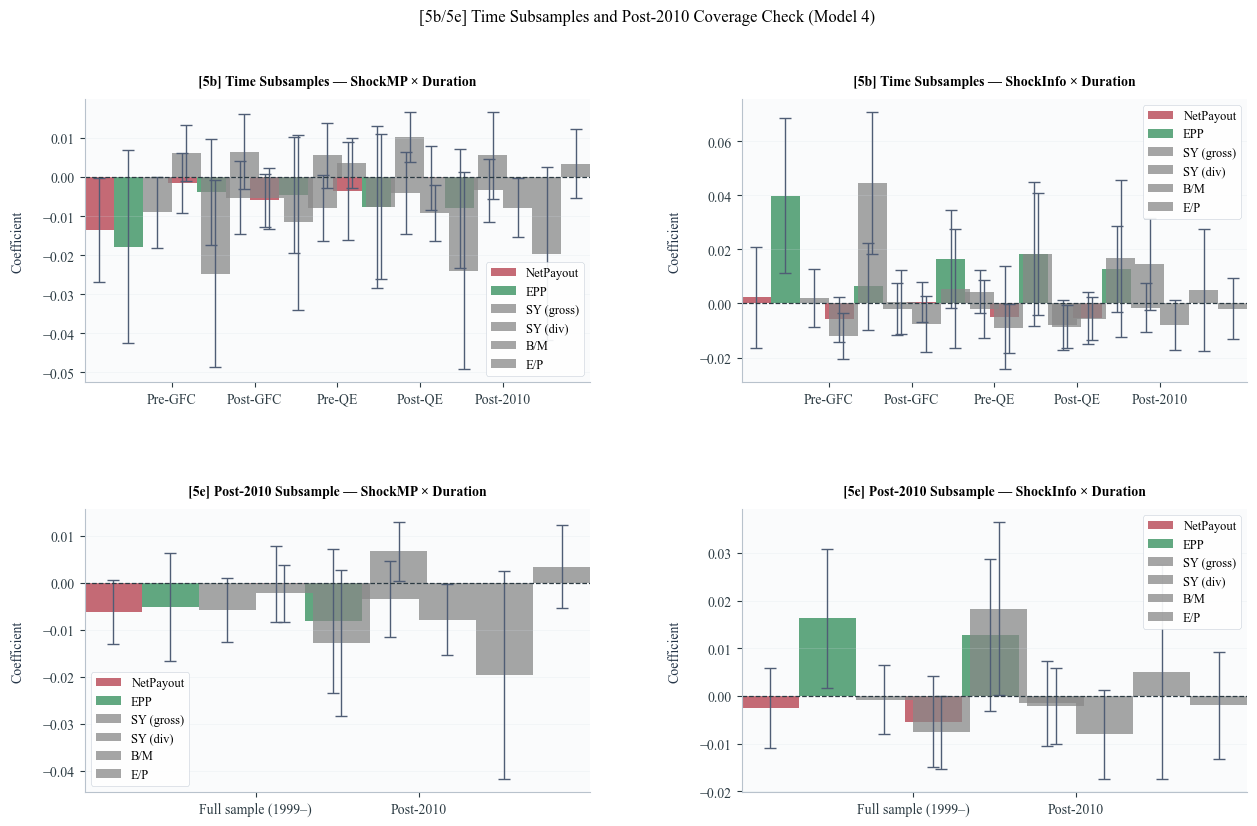

In [41]:
# Plots [5b] and [5e]: combined 2×2 figure saved as rob_5b_5e_time.png
# Duration_Implied is consistently insignificant — omitted from robustness plots
_PLOT_DURS = [d for d in ['Duration_NetPayout_std', 'EPP_std', 'SY_gross_std', 'SY_div_only_std', 'BM_rob_std', 'EP_rob_std'] if d in duration_vars]
_dur_short_rob = {
    'Duration_NetPayout_std': 'NetPayout',
    'EPP_std':                'EPP',
    'SY_gross_std':           'SY (gross)',
    'SY_div_only_std':        'SY (div)',
    'BM_rob_std':             'B/M',
    'EP_rob_std':             'E/P',
}

_5b_labels = ['Pre-GFC (before 2008-09-01)', 'Post-GFC (after 2008-09-01)',
              'Pre-QE (before 2015-01-22)',  'Post-QE (after 2015-01-22)']
_5b_short  = {'Pre-GFC (before 2008-09-01)': 'Pre-GFC',
              'Post-GFC (after 2008-09-01)': 'Post-GFC',
              'Pre-QE (before 2015-01-22)':  'Pre-QE',
              'Post-QE (after 2015-01-22)':  'Post-QE'}
_all_time_labels = _5b_labels + ['Post-2010 (stable coverage)']
_all_short = dict(**_5b_short, **{'Post-2010 (stable coverage)': 'Post-2010'})
_5b5e_df = pd.DataFrame([r for r in new_robust_rows
                          if r.get('subsample') in _all_time_labels])

if not _5b5e_df.empty:
    _w_b = 0.35
    _offsets_b = (np.linspace(-(len(_PLOT_DURS)-1)*_w_b/2,
                               (len(_PLOT_DURS)-1)*_w_b/2, len(_PLOT_DURS))
                  if _PLOT_DURS else np.array([0.]))

    fig, axes = plt.subplots(2, 2, figsize=(15, 9), sharey=False)
    fig.subplots_adjust(hspace=0.45, wspace=0.3)

    # Row 0: [5b] time subsamples bar chart (5 groups)
    _x5b = np.arange(5)
    for _ax, _coef_col, _se_col, _title in [
        (axes[0, 0], 'coef_mp_duration',   'se_mp_duration',   'ShockMP × Duration'),
        (axes[0, 1], 'coef_info_duration', 'se_info_duration', 'ShockInfo × Duration'),
    ]:
        for _dur, _off in zip(_PLOT_DURS, _offsets_b):
            _vals = [float(_5b5e_df[(_5b5e_df['duration_name'] == _dur) &
                                     (_5b5e_df['subsample'] == _l)][_coef_col].iloc[0])
                     if not _5b5e_df[(_5b5e_df['duration_name'] == _dur) &
                                      (_5b5e_df['subsample'] == _l)].empty else np.nan
                     for _l in _all_time_labels]
            _errs = [1.96 * float(_5b5e_df[(_5b5e_df['duration_name'] == _dur) &
                                            (_5b5e_df['subsample'] == _l)][_se_col].iloc[0])
                     if not _5b5e_df[(_5b5e_df['duration_name'] == _dur) &
                                      (_5b5e_df['subsample'] == _l)].empty else np.nan
                     for _l in _all_time_labels]
            _ax.bar(_x5b + _off, _vals, width=_w_b,
                    color=_DUR_COLORS.get(_dur, '#888'), alpha=0.75,
                    label=_dur_short_rob.get(_dur, _dur),
                    yerr=_errs, capsize=4,
                    error_kw={'ecolor': COLORS['neutral'], 'linewidth': 1.0})
        _ax.axhline(0, color=COLORS['reference'], linewidth=0.9, linestyle='--')
        _ax.set_xticks(_x5b)
        _ax.set_xticklabels([_all_short[l] for l in _all_time_labels], fontsize=8)
        _ax.set_ylabel('Coefficient')
        _ax.set_title(f'[5b] Time Subsamples — {_title}', fontsize=10)
        style_axes(_ax, grid_axis='y', grid_alpha=0.2, label_x=-0.12)
        _ax.legend(fontsize=9)

    # Row 1: [5e] Post-2010 vs Full sample bar chart
    _x5e = np.arange(2)
    _w_e = 0.35
    _offsets_e = (np.linspace(-(len(_PLOT_DURS)-1)*_w_e/2,
                               (len(_PLOT_DURS)-1)*_w_e/2, len(_PLOT_DURS))
                  if _PLOT_DURS else np.array([0.]))
    for _ax, _coef_col, _se_col, _title in [
        (axes[1, 0], 'coef_mp_duration',   'se_mp_duration',   'ShockMP × Duration'),
        (axes[1, 1], 'coef_info_duration', 'se_info_duration', 'ShockInfo × Duration'),
    ]:
        for _dur, _off in zip(_PLOT_DURS, _offsets_e):
            _row_full = df_results[
                (df_results['duration_name'] == _dur) &
                (df_results['specification_name'] == 'Model 4: Event FE + all controls') &
                (df_results['depvar'] == 'AR_0')].head(1)
            _row_p = _5b5e_df[(_5b5e_df['duration_name'] == _dur) &
                               (_5b5e_df['subsample'] == 'Post-2010 (stable coverage)')]
            _c_f  = float(_row_full[_coef_col].iloc[0]) if not _row_full.empty else np.nan
            _se_f = float(_row_full[_se_col].iloc[0])   if not _row_full.empty else np.nan
            _c_p  = float(_row_p[_coef_col].iloc[0])    if not _row_p.empty   else np.nan
            _se_p = float(_row_p[_se_col].iloc[0])      if not _row_p.empty   else np.nan
            _ax.bar(_x5e + _off, [_c_f, _c_p], width=_w_e,
                    color=_DUR_COLORS.get(_dur, '#888'), alpha=0.75,
                    label=_dur_short_rob.get(_dur, _dur),
                    yerr=[1.96*_se_f, 1.96*_se_p], capsize=4,
                    error_kw={'ecolor': COLORS['neutral'], 'linewidth': 1.0})
        _ax.axhline(0, color=COLORS['reference'], linewidth=0.9, linestyle='--')
        _ax.set_xticks(_x5e)
        _ax.set_xticklabels(['Full sample (1999–)', 'Post-2010'], fontsize=9)
        _ax.set_ylabel('Coefficient')
        _ax.set_title(f'[5e] Post-2010 Subsample — {_title}', fontsize=10)
        style_axes(_ax, grid_axis='y', grid_alpha=0.2, label_x=-0.12)
        _ax.legend(fontsize=9)

    plt.suptitle('[5b/5e] Time Subsamples and Post-2010 Coverage Check (Model 4)',
                 fontsize=12)
    fig.savefig(GRAPH_DIR / 'rob_5b_5e_time.png', dpi=300, bbox_inches='tight')
    plt.show()

    # Also save individual figures
    # rob_5b_time_subsamples.png — top row only
    fig_b, axes_b = plt.subplots(1, 2, figsize=(13, 5))
    for _ax, _coef_col, _se_col, _title in [
        (axes_b[0], 'coef_mp_duration',   'se_mp_duration',   'ShockMP × Duration'),
        (axes_b[1], 'coef_info_duration', 'se_info_duration', 'ShockInfo × Duration'),
    ]:
        for _dur, _off in zip(_PLOT_DURS, _offsets_b):
            _vals = [float(_5b5e_df[(_5b5e_df['duration_name'] == _dur) &
                                     (_5b5e_df['subsample'] == _l)][_coef_col].iloc[0])
                     if not _5b5e_df[(_5b5e_df['duration_name'] == _dur) &
                                      (_5b5e_df['subsample'] == _l)].empty else np.nan
                     for _l in _all_time_labels]
            _errs = [1.96 * float(_5b5e_df[(_5b5e_df['duration_name'] == _dur) &
                                            (_5b5e_df['subsample'] == _l)][_se_col].iloc[0])
                     if not _5b5e_df[(_5b5e_df['duration_name'] == _dur) &
                                      (_5b5e_df['subsample'] == _l)].empty else np.nan
                     for _l in _all_time_labels]
            _ax.bar(_x5b + _off, _vals, width=_w_b,
                    color=_DUR_COLORS.get(_dur, '#888'), alpha=0.75,
                    label=_dur_short_rob.get(_dur, _dur),
                    yerr=_errs, capsize=4,
                    error_kw={'ecolor': COLORS['neutral'], 'linewidth': 1.0})
        _ax.axhline(0, color=COLORS['reference'], linewidth=0.9, linestyle='--')
        _ax.set_xticks(_x5b)
        _ax.set_xticklabels([_all_short[l] for l in _all_time_labels], fontsize=8)
        _ax.set_ylabel('Coefficient')
        _ax.set_title(f'Time Subsamples — {_title}', fontsize=10)
        style_axes(_ax, grid_axis='y', grid_alpha=0.2, label_x=-0.12)
        _ax.legend(fontsize=9)
    plt.suptitle('[5b] Time Subsamples (Model 4)', fontsize=11)
    plt.tight_layout()
    fig_b.savefig(GRAPH_DIR / 'rob_5b_time_subsamples.png', dpi=300, bbox_inches='tight')
    plt.close(fig_b)

    # rob_5e_post2010.png
    fig_e, axes_e = plt.subplots(1, 2, figsize=(10, 5))
    for _ax, _coef_col, _se_col, _title in [
        (axes_e[0], 'coef_mp_duration',   'se_mp_duration',   'ShockMP × Duration'),
        (axes_e[1], 'coef_info_duration', 'se_info_duration', 'ShockInfo × Duration'),
    ]:
        for _dur, _off in zip(_PLOT_DURS, _offsets_e):
            _row_full = df_results[
                (df_results['duration_name'] == _dur) &
                (df_results['specification_name'] == 'Model 4: Event FE + all controls') &
                (df_results['depvar'] == 'AR_0')].head(1)
            _row_p = _5b5e_df[(_5b5e_df['duration_name'] == _dur) &
                               (_5b5e_df['subsample'] == 'Post-2010 (stable coverage)')]
            _c_f  = float(_row_full[_coef_col].iloc[0]) if not _row_full.empty else np.nan
            _se_f = float(_row_full[_se_col].iloc[0])   if not _row_full.empty else np.nan
            _c_p  = float(_row_p[_coef_col].iloc[0])    if not _row_p.empty   else np.nan
            _se_p = float(_row_p[_se_col].iloc[0])      if not _row_p.empty   else np.nan
            _ax.bar(_x5e + _off, [_c_f, _c_p], width=_w_e,
                    color=_DUR_COLORS.get(_dur, '#888'), alpha=0.75,
                    label=_dur_short_rob.get(_dur, _dur),
                    yerr=[1.96*_se_f, 1.96*_se_p], capsize=4,
                    error_kw={'ecolor': COLORS['neutral'], 'linewidth': 1.0})
        _ax.axhline(0, color=COLORS['reference'], linewidth=0.9, linestyle='--')
        _ax.set_xticks(_x5e)
        _ax.set_xticklabels(['Full sample (1999–)', 'Post-2010'], fontsize=9)
        _ax.set_ylabel('Coefficient')
        _ax.set_title(f'Post-2010 Subsample — {_title}', fontsize=10)
        style_axes(_ax, grid_axis='y', grid_alpha=0.2, label_x=-0.12)
        _ax.legend(fontsize=9)
    plt.suptitle('[5e] Post-2010 Subsample (Stable Coverage Period)', fontsize=11)
    plt.tight_layout()
    fig_e.savefig(GRAPH_DIR / 'rob_5e_post2010.png', dpi=300, bbox_inches='tight')
    plt.close(fig_e)


### 8.4 Influential Events

Removes the 10 largest ECB shock events to test whether results are driven by a small number of extreme observations.

In [42]:
print("=" * 60)
print("SECTION 8.4: INFLUENTIAL EVENTS")
print("=" * 60)

# ── [5c] Exclude top-10 |ShockMP| events ─────────────────────────────────────
print("\n[5c] Exclude top-10 |ShockMP| events")
_top10_events = (
    df_evt[['event_date', 'ShockMP']].drop_duplicates('event_date')
    .assign(abs_shock=lambda d: d['ShockMP'].abs())
    .nlargest(10, 'abs_shock')['event_date'].values
)
print(f"  Excluding: {sorted([str(e)[:10] for e in _top10_events])}")
_df_no_outlier = df_evt[~df_evt['event_date'].isin(_top10_events)].copy()

for _dur in duration_vars:
    _row_excl = run_regression(
        df=_df_no_outlier, depvar='AR_0', duration_var=_dur,
        specification_name='Robustness: Model 4 excl. top-10 |ShockMP| events',
        include_event_fe=True, include_raw_shocks=False,
        controls=ctrl_plus, cluster='event', include_bm=True)
    if _row_excl is not None:
        _row_excl['subsample'] = 'Excl. top-10 |ShockMP| events'
        new_robust_rows.append(_row_excl)
        _row_full = df_results[
            (df_results['duration_name'] == _dur) &
            (df_results['specification_name'] == 'Model 4: Event FE + all controls') &
            (df_results['depvar'] == 'AR_0')].head(1)
        if not _row_full.empty:
            _c_f = float(_row_full['coef_mp_duration'].iloc[0])
            _t_f = float(_row_full['t_mp_duration'].iloc[0])
            _c_e, _t_e = _row_excl['coef_mp_duration'], _row_excl['t_mp_duration']
            print(f"  {_dur}: full coef={_c_f:.4f} (t={_t_f:.2f}) -> "
                  f"excl. coef={_c_e:.4f} (t={_t_e:.2f}), delta={_c_e - _c_f:.4f}")

# Summary table [5c]: before/after comparison
_5c_subs = ['Excl. top-10 |ShockMP| events']
_5c_df = pd.DataFrame([r for r in new_robust_rows if r.get('subsample') in _5c_subs])
if not _5c_df.empty:
    print("\nInfluential Events Exclusion — Before/After Comparison:")
    for _dur in [d for d in ['Duration_NetPayout_std', 'EPP_std'] if d in duration_vars]:
        _rf = df_results[
            (df_results['duration_name'] == _dur) &
            (df_results['specification_name'] == 'Model 4: Event FE + all controls') &
            (df_results['depvar'] == 'AR_0')].head(1)
        _re = _5c_df[_5c_df['duration_name'] == _dur]
        if not _rf.empty and not _re.empty:
            print(f"  {_dur}:")
            print(f"    Full sample: coef_MP={float(_rf['coef_mp_duration'].iloc[0]):.4f} "
                  f"(t={float(_rf['t_mp_duration'].iloc[0]):.2f}), "
                  f"coef_Info={float(_rf['coef_info_duration'].iloc[0]):.4f} "
                  f"(t={float(_rf['t_info_duration'].iloc[0]):.2f})  N={int(_rf['N'].iloc[0]):,}")
            print(f"    Excl. top-10: coef_MP={float(_re['coef_mp_duration'].iloc[0]):.4f} "
                  f"(t={float(_re['t_mp_duration'].iloc[0]):.2f}), "
                  f"coef_Info={float(_re['coef_info_duration'].iloc[0]):.4f} "
                  f"(t={float(_re['t_info_duration'].iloc[0]):.2f})  N={int(_re['N'].iloc[0]):,}")


SECTION 8.4: INFLUENTIAL EVENTS

[5c] Exclude top-10 |ShockMP| events
  Excluding: ['2000-06-08', '2001-05-10', '2008-06-05', '2008-07-03', '2008-11-06', '2011-10-06', '2012-08-02', '2015-12-03', '2020-03-12', '2022-12-15']
  Duration_Implied_std: full coef=-0.0017 (t=-0.34) -> excl. coef=-0.0052 (t=-0.99), delta=-0.0035
  Duration_NetPayout_std: full coef=-0.0062 (t=-1.78) -> excl. coef=-0.0118 (t=-2.19), delta=-0.0057
  EPP_std: full coef=-0.0052 (t=-0.89) -> excl. coef=-0.0073 (t=-0.86), delta=-0.0022
  SY_gross_std: full coef=-0.0058 (t=-1.66) -> excl. coef=-0.0016 (t=-0.36), delta=0.0042
  SY_div_only_std: full coef=-0.0023 (t=-0.73) -> excl. coef=0.0020 (t=0.51), delta=0.0043
  BM_rob_std: full coef=-0.0128 (t=-1.62) -> excl. coef=-0.0167 (t=-1.88), delta=-0.0038
  EP_rob_std: full coef=0.0067 (t=2.10) -> excl. coef=0.0117 (t=2.41), delta=0.0050

Influential Events Exclusion — Before/After Comparison:
  Duration_NetPayout_std:
    Full sample: coef_MP=-0.0062 (t=-1.78), coef_Info

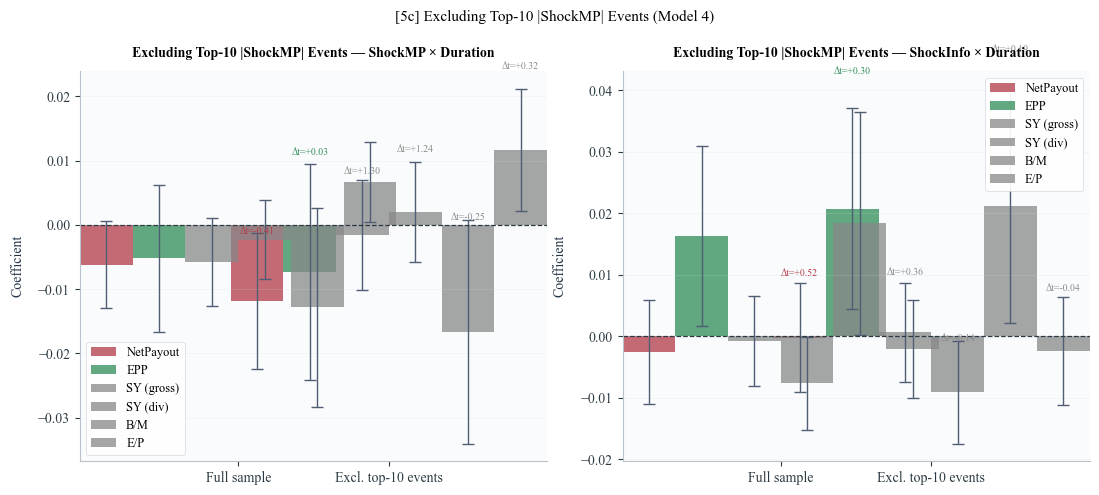

In [43]:
# Plot [5c]: Influential events exclusion
# Duration_Implied is consistently insignificant — omitted from robustness plots
_PLOT_DURS = [d for d in ['Duration_NetPayout_std', 'EPP_std', 'SY_gross_std', 'SY_div_only_std', 'BM_rob_std', 'EP_rob_std'] if d in duration_vars]
_dur_short_rob = {
    'Duration_NetPayout_std': 'NetPayout',
    'EPP_std':                'EPP',
    'SY_gross_std':           'SY (gross)',
    'SY_div_only_std':        'SY (div)',
    'BM_rob_std':             'B/M',
    'EP_rob_std':             'E/P',
}

_5c_df = pd.DataFrame([r for r in new_robust_rows
                        if r.get('subsample') == 'Excl. top-10 |ShockMP| events'])
if not _5c_df.empty:
    _groups = ['Full sample', 'Excl. top-10 events']
    _x_c = np.arange(2)
    _w_c = 0.35
    _offsets_c = (np.linspace(-(len(_PLOT_DURS)-1)*_w_c/2,
                               (len(_PLOT_DURS)-1)*_w_c/2, len(_PLOT_DURS))
                  if _PLOT_DURS else np.array([0.]))
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    for _ax, _coef_col, _se_col, _t_col, _title in [
        (axes[0], 'coef_mp_duration',   'se_mp_duration',   't_mp_duration',   'ShockMP × Duration'),
        (axes[1], 'coef_info_duration', 'se_info_duration', 't_info_duration', 'ShockInfo × Duration'),
    ]:
        for _dur, _off in zip(_PLOT_DURS, _offsets_c):
            _rf = df_results[
                (df_results['duration_name'] == _dur) &
                (df_results['specification_name'] == 'Model 4: Event FE + all controls') &
                (df_results['depvar'] == 'AR_0')].head(1)
            _re = _5c_df[_5c_df['duration_name'] == _dur]
            _c_f  = float(_rf[_coef_col].iloc[0]) if not _rf.empty else np.nan
            _se_f = float(_rf[_se_col].iloc[0])   if not _rf.empty else np.nan
            _t_f  = float(_rf[_t_col].iloc[0])    if not _rf.empty else np.nan
            _c_e  = float(_re[_coef_col].iloc[0]) if not _re.empty else np.nan
            _se_e = float(_re[_se_col].iloc[0])   if not _re.empty else np.nan
            _t_e  = float(_re[_t_col].iloc[0])    if not _re.empty else np.nan
            _bars = _ax.bar(_x_c + _off, [_c_f, _c_e], width=_w_c,
                    color=_DUR_COLORS.get(_dur, '#888'), alpha=0.75,
                    label=_dur_short_rob.get(_dur, _dur),
                    yerr=[1.96*_se_f, 1.96*_se_e], capsize=4,
                    error_kw={'ecolor': COLORS['neutral'], 'linewidth': 1.0})
            # Annotate delta-t above exclusion bar
            if not np.isnan(_t_f) and not np.isnan(_t_e):
                _delta_t = _t_e - _t_f
                _bar_top = (_c_e + 1.96*_se_e) if not np.isnan(_se_e) else _c_e
                _ax.annotate(f"Δt={_delta_t:+.2f}",
                             xy=(_x_c[1] + _off, _bar_top),
                             xytext=(_x_c[1] + _off, _bar_top * 1.15 if _bar_top != 0 else 0.001),
                             fontsize=7, ha='center', color=_DUR_COLORS.get(_dur, '#888'))
        _ax.axhline(0, color=COLORS['reference'], linewidth=0.9, linestyle='--')
        _ax.set_xticks(_x_c)
        _ax.set_xticklabels(_groups, fontsize=9)
        _ax.set_ylabel('Coefficient')
        _ax.set_title(f'Excluding Top-10 |ShockMP| Events — {_title}', fontsize=10)
        style_axes(_ax, grid_axis='y', grid_alpha=0.2, label_x=-0.12)
        _ax.legend(fontsize=9)
    plt.suptitle('[5c] Excluding Top-10 |ShockMP| Events (Model 4)', fontsize=11)
    plt.tight_layout()
    fig.savefig(GRAPH_DIR / 'rob_5c_excl_top10.png', dpi=300, bbox_inches='tight')
    plt.show()


### 8.5 Winsorized Returns

Replaces raw abnormal returns with returns winsorized at 1%/99% per event date to assess sensitivity to outlier firm returns.

In [44]:
print("=" * 60)
print("SECTION 8.5: WINSORIZED RETURNS")
print("=" * 60)

# ── [5d] Winsorized returns ───────────────────────────────────────────────────
print("\n[5d] Winsorized returns (AR_0 winsorized at 1%/99% per event date)")

def _winsorize_by_group(s, lo=0.01, hi=0.99):
    return s.clip(lower=s.quantile(lo), upper=s.quantile(hi))

df_evt['AR_0_wins'] = (
    df_evt.groupby('event_date', dropna=False)['AR_0']
    .transform(lambda s: _winsorize_by_group(s))
)
print(f"AR_0_wins: {df_evt['AR_0_wins'].notna().mean():.1%} coverage, "
      f"mean={df_evt['AR_0_wins'].mean():.4f}, std={df_evt['AR_0_wins'].std():.4f}")

for _dur in duration_vars:
    _row_w = run_regression(
        df=df_evt, depvar='AR_0_wins', duration_var=_dur,
        specification_name='Robustness: Model 4 winsorized returns',
        include_event_fe=True, include_raw_shocks=False,
        controls=ctrl_plus, cluster='event', include_bm=True)
    if _row_w is not None:
        _row_w['subsample'] = 'Winsorized AR_0 (1/99%)'
        new_robust_rows.append(_row_w)
        _row_base = df_results[
            (df_results['duration_name'] == _dur) &
            (df_results['specification_name'] == 'Model 4: Event FE + all controls') &
            (df_results['depvar'] == 'AR_0')].head(1)
        if not _row_base.empty:
            _c_b = float(_row_base['coef_mp_duration'].iloc[0])
            print(f"  {_dur}: AR_0 coef={_c_b:.4f} -> "
                  f"AR_0_wins coef={_row_w['coef_mp_duration']:.4f} "
                  f"(change: {_row_w['coef_mp_duration'] - _c_b:.4f})")

# Summary table [5d]: before/after comparison
_5d_df = pd.DataFrame([r for r in new_robust_rows
                        if r.get('subsample') == 'Winsorized AR_0 (1/99%)'])
if not _5d_df.empty:
    print("\nWinsorized Returns — Before/After Comparison:")
    for _dur in [d for d in ['Duration_NetPayout_std', 'EPP_std'] if d in duration_vars]:
        _rb = df_results[
            (df_results['duration_name'] == _dur) &
            (df_results['specification_name'] == 'Model 4: Event FE + all controls') &
            (df_results['depvar'] == 'AR_0')].head(1)
        _rw = _5d_df[_5d_df['duration_name'] == _dur]
        if not _rb.empty and not _rw.empty:
            print(f"  {_dur}:")
            print(f"    AR_0 (raw):   coef_MP={float(_rb['coef_mp_duration'].iloc[0]):.4f} "
                  f"(t={float(_rb['t_mp_duration'].iloc[0]):.2f})  N={int(_rb['N'].iloc[0]):,}")
            print(f"    AR_0 (wins):  coef_MP={float(_rw['coef_mp_duration'].iloc[0]):.4f} "
                  f"(t={float(_rw['t_mp_duration'].iloc[0]):.2f})  N={int(_rw['N'].iloc[0]):,}")

df_new_robust = pd.DataFrame(new_robust_rows)
if not df_new_robust.empty:
    print(f"\nNew robustness: {len(df_new_robust)} rows, "
          f"{df_new_robust['specification_name'].nunique()} specifications")


SECTION 8.5: WINSORIZED RETURNS

[5d] Winsorized returns (AR_0 winsorized at 1%/99% per event date)
AR_0_wins: 100.0% coverage, mean=0.0001, std=0.0213
  Duration_Implied_std: AR_0 coef=-0.0017 -> AR_0_wins coef=-0.0018 (change: -0.0001)
  Duration_NetPayout_std: AR_0 coef=-0.0062 -> AR_0_wins coef=-0.0053 (change: 0.0008)
  EPP_std: AR_0 coef=-0.0052 -> AR_0_wins coef=-0.0040 (change: 0.0012)
  SY_gross_std: AR_0 coef=-0.0058 -> AR_0_wins coef=-0.0054 (change: 0.0004)
  SY_div_only_std: AR_0 coef=-0.0023 -> AR_0_wins coef=-0.0025 (change: -0.0002)
  BM_rob_std: AR_0 coef=-0.0128 -> AR_0_wins coef=-0.0109 (change: 0.0019)
  EP_rob_std: AR_0 coef=0.0067 -> AR_0_wins coef=0.0060 (change: -0.0006)

Winsorized Returns — Before/After Comparison:
  Duration_NetPayout_std:
    AR_0 (raw):   coef_MP=-0.0062 (t=-1.78)  N=103,200
    AR_0 (wins):  coef_MP=-0.0053 (t=-1.63)  N=103,200
  EPP_std:
    AR_0 (raw):   coef_MP=-0.0052 (t=-0.89)  N=112,388
    AR_0 (wins):  coef_MP=-0.0040 (t=-0.75)  N=

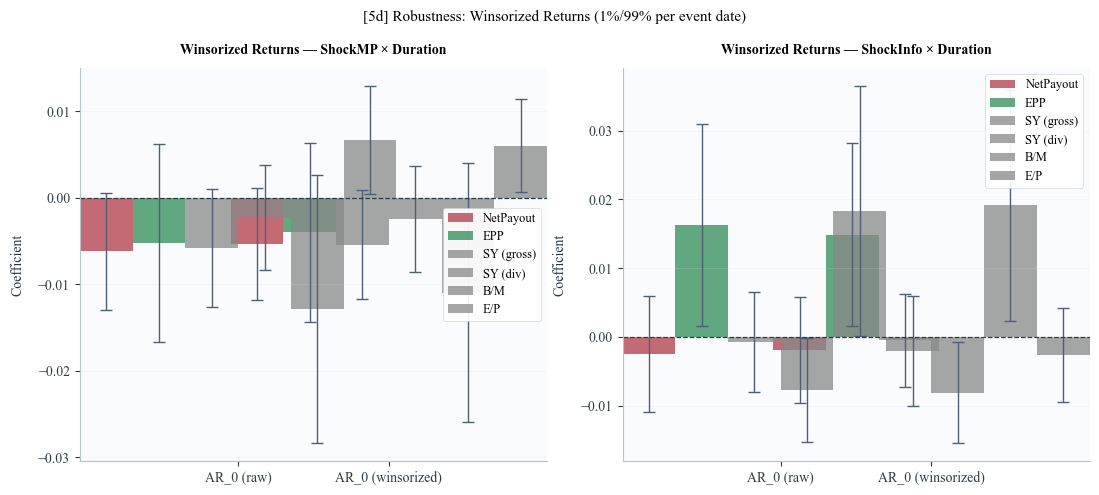

In [45]:
# Plot [5d]: Winsorized returns
# Duration_Implied is consistently insignificant — omitted from robustness plots
_PLOT_DURS = [d for d in ['Duration_NetPayout_std', 'EPP_std', 'SY_gross_std', 'SY_div_only_std', 'BM_rob_std', 'EP_rob_std'] if d in duration_vars]
_dur_short_rob = {
    'Duration_NetPayout_std': 'NetPayout',
    'EPP_std':                'EPP',
    'SY_gross_std':           'SY (gross)',
    'SY_div_only_std':        'SY (div)',
    'BM_rob_std':             'B/M',
    'EP_rob_std':             'E/P',
}

_5d_df = pd.DataFrame([r for r in new_robust_rows
                        if r.get('subsample') == 'Winsorized AR_0 (1/99%)'])
if not _5d_df.empty:
    _groups = ['AR_0 (raw)', 'AR_0 (winsorized)']
    _x_d = np.arange(2)
    _w_d = 0.35
    _offsets_d = (np.linspace(-(len(_PLOT_DURS)-1)*_w_d/2,
                               (len(_PLOT_DURS)-1)*_w_d/2, len(_PLOT_DURS))
                  if _PLOT_DURS else np.array([0.]))
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    for _ax, _coef_col, _se_col, _title in [
        (axes[0], 'coef_mp_duration',   'se_mp_duration',   'ShockMP × Duration'),
        (axes[1], 'coef_info_duration', 'se_info_duration', 'ShockInfo × Duration'),
    ]:
        for _dur, _off in zip(_PLOT_DURS, _offsets_d):
            _rb = df_results[
                (df_results['duration_name'] == _dur) &
                (df_results['specification_name'] == 'Model 4: Event FE + all controls') &
                (df_results['depvar'] == 'AR_0')].head(1)
            _rw = _5d_df[_5d_df['duration_name'] == _dur]
            _c_b  = float(_rb[_coef_col].iloc[0]) if not _rb.empty else np.nan
            _se_b = float(_rb[_se_col].iloc[0])   if not _rb.empty else np.nan
            _c_w  = float(_rw[_coef_col].iloc[0]) if not _rw.empty else np.nan
            _se_w = float(_rw[_se_col].iloc[0])   if not _rw.empty else np.nan
            _ax.bar(_x_d + _off, [_c_b, _c_w], width=_w_d,
                    color=_DUR_COLORS.get(_dur, '#888'), alpha=0.75,
                    label=_dur_short_rob.get(_dur, _dur),
                    yerr=[1.96*_se_b, 1.96*_se_w], capsize=4,
                    error_kw={'ecolor': COLORS['neutral'], 'linewidth': 1.0})
        _ax.axhline(0, color=COLORS['reference'], linewidth=0.9, linestyle='--')
        _ax.set_xticks(_x_d)
        _ax.set_xticklabels(_groups, fontsize=9)
        _ax.set_ylabel('Coefficient')
        _ax.set_title(f'Winsorized Returns — {_title}', fontsize=10)
        style_axes(_ax, grid_axis='y', grid_alpha=0.2, label_x=-0.12)
        _ax.legend(fontsize=9)
    plt.suptitle('[5d] Robustness: Winsorized Returns (1%/99% per event date)',
                 fontsize=11)
    plt.tight_layout()
    fig.savefig(GRAPH_DIR / 'rob_5d_winsorized.png', dpi=300, bbox_inches='tight')
    plt.show()


### 8.6 Robustness Summary Table

Compact overview of all robustness check results (Sections 8.2–8.5). Duration_Implied_std omitted (consistently insignificant across all checks).

In [46]:
print("=" * 60)
print("SECTION 8.6: ROBUSTNESS SUMMARY TABLE")
print("=" * 60)

# Collect all new robustness results
# Duration_Implied_std omitted — consistently insignificant across all checks
_SHOW_DURS = [d for d in ['Duration_NetPayout_std', 'EPP_std'] if d in duration_vars]

if 'df_new_robust' in dir() and not df_new_robust.empty:
    _rob_show = df_new_robust[
        df_new_robust['duration_name'].isin(_SHOW_DURS)
    ].copy()

    # Build compact display columns
    _rob_show['MP_coef_t'] = (
        _rob_show['coef_mp_duration'].round(4).astype(str) + ' (' +
        _rob_show['t_mp_duration'].round(2).astype(str) + ')'
    )
    _rob_show['Info_coef_t'] = (
        _rob_show['coef_info_duration'].round(4).astype(str) + ' (' +
        _rob_show['t_info_duration'].round(2).astype(str) + ')'
    )
    _rob_show['Check'] = _rob_show['subsample']
    _rob_show['Duration'] = _rob_show['duration_name'].str.replace('_std', '').str.replace('Duration_', '')

    _summary_cols = ['Check', 'Duration', 'N', 'MP_coef_t', 'Info_coef_t']
    _summary = _rob_show[_summary_cols].sort_values(['Check', 'Duration']).reset_index(drop=True)

    print("\nRobustness Summary (Duration_NetPayout_std and EPP_std only):")
    print(_summary.to_string(index=False))

    # Save to CSV
    _summary.to_csv(TABLE_DIR / 'regression_results_robustness_summary.csv', index=False)
    print(f"\nSaved: {TABLE_DIR / 'regression_results_robustness_summary.csv'}")
else:
    print("df_new_robust not available — run sections 8.2–8.5 first.")


SECTION 8.6: ROBUSTNESS SUMMARY TABLE

Robustness Summary (Duration_NetPayout_std and EPP_std only):
                        Check  Duration      N       MP_coef_t     Info_coef_t
Excl. top-10 |ShockMP| events       EPP 108700 -0.0073 (-0.86)   0.0207 (2.48)
Excl. top-10 |ShockMP| events NetPayout  99715 -0.0118 (-2.19) -0.0003 (-0.06)
  Post-2010 (stable coverage)       EPP  57746  -0.008 (-1.03)   0.0128 (1.58)
  Post-2010 (stable coverage) NetPayout  56155 -0.0003 (-0.07) -0.0054 (-1.12)
  Post-GFC (after 2008-09-01)       EPP  63862 -0.0038 (-0.56)   0.0063 (0.77)
  Post-GFC (after 2008-09-01) NetPayout  62034  -0.0016 (-0.4) -0.0059 (-1.39)
   Post-QE (after 2015-01-22)       EPP  34068 -0.0077 (-0.73)   0.0182 (1.34)
   Post-QE (after 2015-01-22) NetPayout  33163 -0.0036 (-0.56) -0.0051 (-0.52)
  Pre-GFC (before 2008-09-01)       EPP  48526 -0.0178 (-1.41)     0.04 (2.71)
  Pre-GFC (before 2008-09-01) NetPayout  41166 -0.0137 (-2.02)   0.0023 (0.24)
   Pre-QE (before 2015-01-22) 

### 8.7 Extreme Duration Portfolios (Q20 vs Q80)

Rationale: The continuous interaction of shocks with standardized duration may dilute the signal by including firms near the center of the duration distribution. This section follows the portfolio-sort logic of Gonçalves (2020) by restricting the sample to firms in the bottom 20% (short duration) and top 20% (long duration) of the cross-sectional distribution, computed separately for each event year (year_pred). A Long-Short indicator variable is assigned: +1 for short-duration firms (Q20), -1 for long-duration firms (Q80), and firms in between are excluded. The regression then estimates whether short-duration firms react more strongly to monetary policy shocks than long-duration firms.

In [47]:
print("=" * 60)
print("SECTION 8.7: EXTREME DURATION PORTFOLIOS (Q20 vs Q80)")
print("=" * 60)

QUANTILE_LO = 0.20
QUANTILE_HI = 0.80

# Duration measures to use for portfolio sort
# (raw, unstandardized — quantiles are computed on raw values)
_port_dur_map = {
    'Duration_NetPayout': 'port_ls_NetPayout',
    'EPP_w':             'port_ls_EPP',
}

# For each duration measure: assign +1 (long = Q80) / -1 (short = Q20)
# / NaN (middle) per event year cross-section
for _raw_col, _ls_col in _port_dur_map.items():
    if _raw_col not in df_evt.columns:
        print(f"WARNING: {_raw_col} not found — skipping.")
        continue

    def _assign_ls(s):
        s = pd.to_numeric(s, errors='coerce')
        q_lo = s.quantile(QUANTILE_LO)
        q_hi = s.quantile(QUANTILE_HI)
        out  = pd.Series(np.nan, index=s.index)
        out[s <= q_lo] = -1.0   # short duration → negative end
        out[s >= q_hi] =  1.0   # long duration  → reference (+1)
        return out

    df_evt[_ls_col] = df_evt.groupby('year_pred')[_raw_col].transform(_assign_ls)

    _n_short = (df_evt[_ls_col] ==  1.0).sum()
    _n_long  = (df_evt[_ls_col] == -1.0).sum()
    _n_mid   = df_evt[_ls_col].isna().sum()
    print(f"{_raw_col}: short (Q20)={_n_short:,}  long (Q80)={_n_long:,}  "
          f"excluded (middle)={_n_mid:,}")

# NOTE: do NOT zscore the LS indicator — it is already a binary contrast variable.
# Keep as-is. Just add to a list for the regression loop.
_ls_vars = [c for c in _port_dur_map.values() if c in df_evt.columns]
print(f"\nLong-Short portfolio variables: {_ls_vars}")

# ── Run portfolio regressions ────────────────────────────────────────────────
# Specification: same as Model 4 (Event FE + all controls + bm)
# but duration_var is replaced by the Long-Short indicator.
# Controls are still standardized by year (beta_std, log_mcap_std,
# leverage_std, bm_std) — same as main models.
# The LS indicator enters the interaction directly without z-scoring.

_port_rows = []

# Sub-function: run one portfolio regression
def _run_port_reg(df_sub, ls_var, depvar, spec_name, subsample_label=None):
    # Regression: depvar ~ ShockMP:ls_var + ShockInfo:ls_var
    #                     + ShockMP:beta_std + ShockInfo:beta_std
    #                     + ShockMP:log_mcap_std + ShockInfo:log_mcap_std
    #                     + ShockMP:leverage_std + ShockInfo:leverage_std
    #                     + ShockMP:bm_std + ShockInfo:bm_std
    #                     + C(event_date)
    # Sample restricted to firms where ls_var is not NaN (Q20 or Q80 only).
    # Clustered SEs by event_date.
    _ctrl_cols = ['beta_std', 'log_mcap_std', 'leverage_std', 'bm_std']
    _needed = ([depvar, 'ShockMP', 'ShockInfo', ls_var, 'event_date', 'firm_id']
               + [c for c in _ctrl_cols if c in df_sub.columns])
    _work = df_sub[_needed].dropna().copy()
    # Restrict to Q20/Q80 only (ls_var != NaN already handled by dropna)
    _work = _work[_work[ls_var].isin([1.0, -1.0])].copy()
    if len(_work) < 100 or _work['event_date'].nunique() < 10:
        return None

    _ctrl_terms = []
    for _c in _ctrl_cols:
        if _c in _work.columns:
            _ctrl_terms += [f'ShockMP:{_c}', f'ShockInfo:{_c}']

    _formula = (f'{depvar} ~ ShockMP:{ls_var} + ShockInfo:{ls_var} '
                + ('+ ' + ' + '.join(_ctrl_terms) if _ctrl_terms else '')
                + ' + C(event_date)')

    _model  = smf.ols(formula=_formula, data=_work)
    _groups = pd.Categorical(_work['event_date']).codes
    _res    = _model.fit(cov_type='cluster', cov_kwds={'groups': _groups})

    _mp_term   = f'ShockMP:{ls_var}'
    _info_term = f'ShockInfo:{ls_var}'

    _row = {
        'ls_var':               ls_var,
        'depvar':               depvar,
        'specification':        spec_name,
        'subsample':            subsample_label or 'Full sample',
        'N':                    int(_res.nobs),
        'n_short':              int((_work[ls_var] ==  1.0).sum()),
        'n_long':               int((_work[ls_var] == -1.0).sum()),
        'n_events':             int(_work['event_date'].nunique()),
        'n_clusters':           int(_work['event_date'].nunique()),
        'coef_mp':              _safe_get(_res.params,  _mp_term),
        'se_mp':                _safe_get(_res.bse,     _mp_term),
        't_mp':                 _safe_get(_res.tvalues, _mp_term),
        'p_mp':                 _safe_get(_res.pvalues, _mp_term),
        'coef_info':            _safe_get(_res.params,  _info_term),
        'se_info':              _safe_get(_res.bse,     _info_term),
        't_info':               _safe_get(_res.tvalues, _info_term),
        'p_info':               _safe_get(_res.pvalues, _info_term),
        'r_squared_adj':        float(_res.rsquared_adj),
        'model_obj':            _res,
    }
    return _row

# Full sample
for _ls in _ls_vars:
    for _dep in ['AR_0', 'AR_0_1']:
        _r = _run_port_reg(df_evt, _ls, _dep,
                           'Q20 vs Q80: Full sample (Event FE)')
        if _r: _port_rows.append(_r)

# Pre-GFC subsample (before 2008-09-01)
_df_pregfc = df_evt[df_evt['event_date'] < pd.Timestamp('2008-09-01')].copy()
for _ls in _ls_vars:
    _r = _run_port_reg(_df_pregfc, _ls, 'AR_0',
                       'Q20 vs Q80: Pre-GFC (Event FE)',
                       subsample_label='Pre-GFC (before 2008-09-01)')
    if _r: _port_rows.append(_r)

# Post-GFC subsample (from 2008-09-01)
_df_postgfc = df_evt[df_evt['event_date'] >= pd.Timestamp('2008-09-01')].copy()
for _ls in _ls_vars:
    _r = _run_port_reg(_df_postgfc, _ls, 'AR_0',
                       'Q20 vs Q80: Post-GFC (Event FE)',
                       subsample_label='Post-GFC (from 2008-09-01)')
    if _r: _port_rows.append(_r)

# Pre-QE subsample (before 2015-01-22)
_df_preqe = df_evt[df_evt['event_date'] < pd.Timestamp('2015-01-22')].copy()
for _ls in _ls_vars:
    _r = _run_port_reg(_df_preqe, _ls, 'AR_0',
                       'Q20 vs Q80: Pre-QE (Event FE)',
                       subsample_label='Pre-QE (before 2015-01-22)')
    if _r: _port_rows.append(_r)

# Post-QE subsample (from 2015-01-22)
_df_postqe = df_evt[df_evt['event_date'] >= pd.Timestamp('2015-01-22')].copy()
for _ls in _ls_vars:
    _r = _run_port_reg(_df_postqe, _ls, 'AR_0',
                       'Q20 vs Q80: Post-QE (Event FE)',
                       subsample_label='Post-QE (from 2015-01-22)')
    if _r: _port_rows.append(_r)

df_port = pd.DataFrame(_port_rows)

# ── Print summary table ───────────────────────────────────────────────────────
print("\nQ20 vs Q80 Portfolio Regression Results:")
print("Interpretation: negative coef_mp = long-duration firms react MORE")
print("NEGATIVELY to a positive ShockMP (monetary tightening) than")
print("short-duration firms — consistent with duration theory.")
print("Long duration (+1) vs short duration (-1).")
print("Expected sign: NEGATIVE (tightening hurts long duration more).\n")

_print_cols = ['subsample', 'ls_var', 'depvar', 'N', 'n_short', 'n_long',
               'n_events', 'coef_mp', 't_mp', 'p_mp',
               'coef_info', 't_info', 'p_info']
_print_df = df_port[_print_cols].copy()
_print_df['stars_mp']   = _print_df['p_mp'].apply(_sig_stars)
_print_df['stars_info'] = _print_df['p_info'].apply(_sig_stars)
_print_df['MP_coef_t']   = _print_df.apply(
    lambda r: f"{r['coef_mp']:.4f}{r['stars_mp']} ({r['t_mp']:.2f})", axis=1)
_print_df['Info_coef_t'] = _print_df.apply(
    lambda r: f"{r['coef_info']:.4f}{r['stars_info']} ({r['t_info']:.2f})", axis=1)

print(_print_df[['subsample','ls_var','depvar','N','n_events',
                  'MP_coef_t','Info_coef_t']].to_string(index=False))


SECTION 8.7: EXTREME DURATION PORTFOLIOS (Q20 vs Q80)
Duration_NetPayout: short (Q20)=21,244  long (Q80)=21,201  excluded (middle)=87,065
EPP_w: short (Q20)=23,605  long (Q80)=23,560  excluded (middle)=82,345

Long-Short portfolio variables: ['port_ls_NetPayout', 'port_ls_EPP']

Q20 vs Q80 Portfolio Regression Results:
Interpretation: negative coef_mp = long-duration firms react MORE
NEGATIVELY to a positive ShockMP (monetary tightening) than
short-duration firms — consistent with duration theory.
Long duration (+1) vs short duration (-1).
Expected sign: NEGATIVE (tightening hurts long duration more).

                  subsample            ls_var depvar     N  n_events        MP_coef_t       Info_coef_t
                Full sample port_ls_NetPayout   AR_0 41517       312  -0.0091 (-1.44)   -0.0106 (-1.29)
                Full sample port_ls_NetPayout AR_0_1 41264       312  -0.0061 (-0.71)   -0.0013 (-0.09)
                Full sample       port_ls_EPP   AR_0 44702       312  -0.0095 

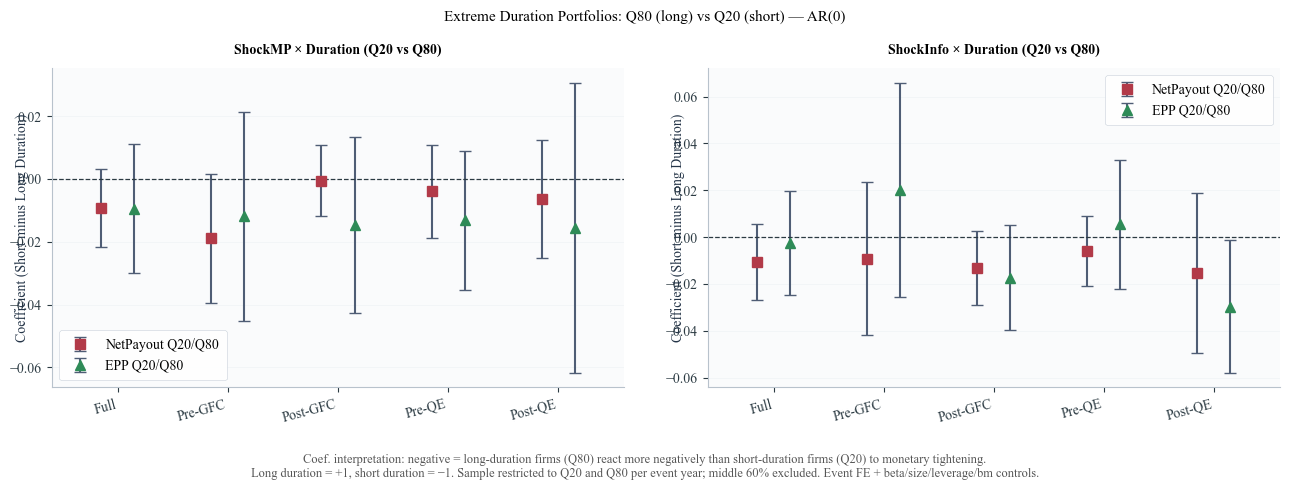

Saved: rob_8_7_portfolio_q20q80.png
Saved: regression_results_portfolio_q20q80.csv (12 rows)


In [48]:
# ── Plot: Q20 vs Q80 coefficients by subsample ───────────────────────────────
# Show ShockMP and ShockInfo side by side, for each subsample,
# separately for NetPayout and EPP LS variables.

try:
    if df_port.empty:
        raise ValueError("df_port is empty — no portfolio regressions succeeded.")

    _subsamples_order = [
        'Full sample',
        'Pre-GFC (before 2008-09-01)',
        'Post-GFC (from 2008-09-01)',
        'Pre-QE (before 2015-01-22)',
        'Post-QE (from 2015-01-22)',
    ]
    _ls_labels = {
        'port_ls_NetPayout': 'NetPayout Q20/Q80',
        'port_ls_EPP':       'EPP Q20/Q80',
    }
    _ls_colors = {
        'port_ls_NetPayout': COLORS.get('accent', '#e07b39'),
        'port_ls_EPP':       COLORS.get('green',  '#2ca02c'),
    }
    _ls_markers = {
        'port_ls_NetPayout': 's',
        'port_ls_EPP':       '^',
    }

    # Filter to AR_0 only for clarity
    _pdf = df_port[df_port['depvar'] == 'AR_0'].copy()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
    fig.subplots_adjust(bottom=0.28)

    for _ax, _coef_col, _se_col, _t_col, _shock_label in [
        (axes[0], 'coef_mp',   'se_mp',   't_mp',   'ShockMP × Duration (Q20 vs Q80)'),
        (axes[1], 'coef_info', 'se_info', 't_info', 'ShockInfo × Duration (Q20 vs Q80)'),
    ]:
        _x = np.arange(len(_subsamples_order))
        _w = 0.3
        _offsets = [-_w/2, _w/2]

        for (_ls, _offset) in zip(_ls_vars, _offsets):
            _coefs = []
            _ses   = []
            for _sub in _subsamples_order:
                _row = _pdf[(_pdf['ls_var'] == _ls) & (_pdf['subsample'] == _sub)]
                if _row.empty:
                    _coefs.append(np.nan)
                    _ses.append(np.nan)
                else:
                    _coefs.append(float(_row[_coef_col].iloc[0]))
                    _ses.append(float(_row[_se_col].iloc[0]))

            _coefs = np.array(_coefs, dtype=float)
            _ses   = np.array(_ses,   dtype=float)

            _ax.errorbar(
                _x + _offset, _coefs,
                yerr=1.96 * _ses,
                fmt=_ls_markers[_ls],
                color=_ls_colors[_ls],
                ecolor=COLORS.get('neutral', '#aaaaaa'),
                capsize=4, markersize=7, linewidth=1.5,
                label=_ls_labels[_ls],
            )

        _ax.axhline(0, color=COLORS.get('reference', '#888888'),
                    linewidth=0.9, linestyle='--')
        _ax.set_xticks(_x)
        _ax.set_xticklabels(
            ['Full', 'Pre-GFC', 'Post-GFC', 'Pre-QE', 'Post-QE'],
            fontsize=9, rotation=15, ha='right')
        _ax.set_xlim(-0.6, len(_subsamples_order) - 0.4)
        _ax.set_title(_shock_label, fontsize=10)
        _ax.set_ylabel('Coefficient (Short minus Long Duration)')
        style_axes(_ax, grid_axis='y', grid_alpha=0.2)
        style_legend(_ax, loc='best')

    fig.text(
        0.5, 0.04,
        'Coef. interpretation: negative = long-duration firms (Q80) react '
        'more negatively than short-duration firms (Q20) to monetary tightening.\n'
        'Long duration = +1, short duration = −1. '
        'Sample restricted to Q20 and Q80 per event year; middle 60% excluded. '
        'Event FE + beta/size/leverage/bm controls.',
        ha='center', va='bottom', fontsize=9, color='#555555'
    )
    plt.suptitle(
        'Extreme Duration Portfolios: Q80 (long) vs Q20 (short) — AR(0)',
        fontsize=11)
    plt.tight_layout(rect=[0, 0.12, 1, 1], w_pad=3)
    fig.savefig(GRAPH_DIR / 'rob_8_7_portfolio_q20q80.png',
                dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: rob_8_7_portfolio_q20q80.png")

    # ── Export portfolio results ──────────────────────────────────────────────
    _port_export = df_port.drop(columns=['model_obj'], errors='ignore').copy()
    _port_export.to_csv(
        TABLE_DIR / 'regression_results_portfolio_q20q80.csv', index=False)
    print(f"Saved: regression_results_portfolio_q20q80.csv "
          f"({len(_port_export)} rows)")

except (ValueError, KeyError, AttributeError) as _e:
    print(f"WARNING: Section 8.7 plot skipped — {_e}")


## 10. Build tidy results tables

In [49]:
print("=" * 60)
print("SECTION 10: BUILD TIDY RESULTS TABLES")
print("=" * 60)

def _duration_label(x):
    return x.replace('_std', '').replace('Duration_', '')

tbl = df_results.copy()
tbl['Duration']      = tbl['duration_name'].map(_duration_label)
tbl['Specification'] = tbl['specification_name']
tbl['Event FE']      = tbl['event_FE']
tbl['Controls']      = tbl['controls']

for c in ['coef_mp_duration', 't_mp_duration', 'p_mp_duration',
          'coef_info_duration', 't_info_duration', 'p_info_duration',
          'r_squared_adj']:
    tbl[c] = pd.to_numeric(tbl[c], errors='coerce')

table_cols = [
    'Duration', 'Specification', 'Event FE', 'Controls',
    'coef_mp_duration', 't_mp_duration', 'p_mp_duration',
    'coef_info_duration', 't_info_duration', 'p_info_duration',
    'N', 'n_events', 'n_clusters', 'r_squared_adj',
]
col_rename = {
    'coef_mp_duration':   'ShockMP x Duration',
    't_mp_duration':      't-stat MP',
    'p_mp_duration':      'p-value MP',
    'coef_info_duration': 'ShockInfo x Duration',
    't_info_duration':    't-stat Info',
    'p_info_duration':    'p-value Info',
    'n_events':           'Events',
    'n_clusters':         'Clusters',
    'r_squared_adj':      'Adj. R2',
}

TABLE_A = tbl[tbl['depvar'] == 'AR_0'][table_cols].rename(columns=col_rename).copy()
TABLE_B = tbl[tbl['depvar'] == 'AR_0_1'][table_cols].rename(columns=col_rename).copy()

for _t in [TABLE_A, TABLE_B]:
    for c in ['ShockMP x Duration', 't-stat MP', 'p-value MP',
              'ShockInfo x Duration', 't-stat Info', 'p-value Info', 'Adj. R2']:
        if c in _t.columns:
            _t[c] = _t[c].map(lambda v: f'{v:.4f}' if pd.notna(v) else '')

# Reader table: coef*** (t-stat) format
# FIX: pass actual p-values (previously np.nan was passed, suppressing all stars)
reader = tbl.copy()
reader['ShockMP x Duration'] = reader.apply(
    lambda r: make_reader_entry(r['coef_mp_duration'], r['t_mp_duration'], r['p_mp_duration']),
    axis=1)
reader['ShockInfo x Duration'] = reader.apply(
    lambda r: make_reader_entry(r['coef_info_duration'], r['t_info_duration'], r['p_info_duration']),
    axis=1)
TABLE_READER = reader[['depvar', 'Duration', 'Specification', 'Event FE', 'Controls',
                         'ShockMP x Duration', 'ShockInfo x Duration',
                         'N', 'n_events', 'n_clusters', 'r_squared_adj']].rename(
    columns={'depvar': 'Return window', 'n_events': 'Events',
             'n_clusters': 'Clusters', 'r_squared_adj': 'Adj. R2'})

print('TABLE A: AR_0 (event-day return)')
display(TABLE_A)
print('\nTABLE B: AR_0_1 (two-day return)')
display(TABLE_B)
print('\nReader table — coef*** (t-stat):')
display(TABLE_READER)

SECTION 10: BUILD TIDY RESULTS TABLES
TABLE A: AR_0 (event-day return)


,Duration,Specification,Event FE,Controls,ShockMP x Duration,t-stat MP,p-value MP,ShockInfo x Duration,t-stat Info,p-value Info,N,Events,Clusters,Adj. R2
0,Implied,Model 1: Baseline,No,None,0.0008,0.1241,0.9012,0.0068,1.4351,0.1513,107885,312,312,0.0166
1,Implied,Model 2: + beta,No,beta,0.0007,0.0938,0.9253,0.0082,1.6868,0.0916,107493,312,312,0.0224
2,Implied,Model 3: + size/leverage,No,"beta, size, leverage",-0.0020,-0.4106,0.6814,0.0056,1.4052,0.1600,105297,312,312,0.0262
3,Implied,Model 4: Event FE + all controls,Yes,"beta, size, leverage",-0.0017,-0.3388,0.7348,0.0015,0.3606,0.7184,105297,312,312,0.0848
4,Implied,Model 5: No Event FE + raw shocks,No,"beta, size, leverage",-0.0020,-0.4106,0.6814,0.0056,1.4052,0.1600,105297,312,312,0.0262
5,NetPayout,Model 1: Baseline,No,None,-0.0061,-1.5330,0.1253,0.0022,0.4917,0.6230,105293,312,312,0.0150
6,NetPayout,Model 2: + beta,No,beta,-0.0078,-2.1689,0.0301,0.0056,1.4802,0.1388,103200,312,312,0.0212
7,NetPayout,Model 3: + size/leverage,No,"beta, size, leverage",-0.0046,-1.1930,0.2329,0.0021,0.5397,0.5894,103200,312,312,0.0248
8,NetPayout,Model 4: Event FE + all controls,Yes,"beta, size, leverage",-0.0062,-1.7814,0.0748,-0.0025,-0.5841,0.5592,103200,312,312,0.0812
9,NetPayout,Model 5: No Event FE + raw shocks,No,"beta, size, leverage",-0.0046,-1.1930,0.2329,0.0021,0.5397,0.5894,103200,312,312,0.0248



TABLE B: AR_0_1 (two-day return)


,Duration,Specification,Event FE,Controls,ShockMP x Duration,t-stat MP,p-value MP,ShockInfo x Duration,t-stat Info,p-value Info,N,Events,Clusters,Adj. R2
35,Implied,Model 1: Baseline,No,None,0.0043,0.4578,0.6471,0.0027,0.3777,0.7057,107191,312,312,0.0059
36,Implied,Model 2: + beta,No,beta,0.0038,0.3973,0.6911,0.0041,0.5563,0.5780,106809,312,312,0.0095
37,Implied,Model 3: + size/leverage,No,"beta, size, leverage",0.0007,0.0930,0.9259,0.0008,0.1293,0.8971,104628,312,312,0.0110
38,Implied,Model 4: Event FE + all controls,Yes,"beta, size, leverage",-0.0010,-0.1353,0.8924,-0.0042,-0.6203,0.5350,104628,312,312,0.0746
39,Implied,Model 5: No Event FE + raw shocks,No,"beta, size, leverage",0.0007,0.0930,0.9259,0.0008,0.1293,0.8971,104628,312,312,0.0110
40,NetPayout,Model 1: Baseline,No,None,-0.0036,-0.6398,0.5223,0.0030,0.4106,0.6813,104629,312,312,0.0049
41,NetPayout,Model 2: + beta,No,beta,-0.0061,-1.1908,0.2337,0.0066,1.0072,0.3138,102571,312,312,0.0089
42,NetPayout,Model 3: + size/leverage,No,"beta, size, leverage",-0.0034,-0.6448,0.5191,0.0033,0.4949,0.6207,102571,312,312,0.0104
43,NetPayout,Model 4: Event FE + all controls,Yes,"beta, size, leverage",-0.0084,-1.6351,0.1020,-0.0007,-0.0908,0.9277,102571,312,312,0.0711
44,NetPayout,Model 5: No Event FE + raw shocks,No,"beta, size, leverage",-0.0034,-0.6448,0.5191,0.0033,0.4949,0.6207,102571,312,312,0.0104



Reader table — coef*** (t-stat):


,Return window,Duration,Specification,Event FE,Controls,ShockMP x Duration,ShockInfo x Duration,N,Events,Clusters,Adj. R2
0,AR_0,Implied,Model 1: Baseline,No,None,0.0008 (0.12),0.0068 (1.44),107885,312,312,0.016620
1,AR_0,Implied,Model 2: + beta,No,beta,0.0007 (0.09),0.0082* (1.69),107493,312,312,0.022404
2,AR_0,Implied,Model 3: + size/leverage,No,"beta, size, leverage",-0.0020 (-0.41),0.0056 (1.41),105297,312,312,0.026239
3,AR_0,Implied,Model 4: Event FE + all controls,Yes,"beta, size, leverage",-0.0017 (-0.34),0.0015 (0.36),105297,312,312,0.084823
4,AR_0,Implied,Model 5: No Event FE + raw shocks,No,"beta, size, leverage",-0.0020 (-0.41),0.0056 (1.41),105297,312,312,0.026239
...,...,...,...,...,...,...,...,...,...,...,...
65,AR_0_1,EP_rob,Model 1: Baseline,No,None,0.0060 (1.11),-0.0034 (-0.60),119942,312,312,0.005407
66,AR_0_1,EP_rob,Model 2: + beta,No,beta,0.0025 (0.50),0.0003 (0.06),116611,312,312,0.008991
67,AR_0_1,EP_rob,Model 3: + size/leverage,No,"beta, size, leverage",0.0050 (1.08),0.0015 (0.26),114918,312,312,0.010628
68,AR_0_1,EP_rob,Model 4: Event FE + all controls,Yes,"beta, size, leverage",0.0064 (1.41),0.0040 (0.65),114057,312,312,0.073754


## 11. Side-by-side comparison tables

In [50]:
print("=" * 60)
print("SECTION 11: COMPARISON TABLES")
print("=" * 60)

compact = tbl[['depvar', 'duration_name', 'specification_name', 'event_FE',
               'coef_mp_duration', 'coef_info_duration',
               't_mp_duration', 't_info_duration',
               'p_mp_duration', 'p_info_duration']].copy()

# FIX: pass actual p-values so significance stars appear (was np.nan before)
compact['mp_reader']   = compact.apply(
    lambda r: make_reader_entry(r['coef_mp_duration'],   r['t_mp_duration'],   r['p_mp_duration']),   axis=1)
compact['info_reader'] = compact.apply(
    lambda r: make_reader_entry(r['coef_info_duration'], r['t_info_duration'], r['p_info_duration']), axis=1)

# CMP_1: All duration measures side by side (AR_0)
CMP_1 = (
    compact[compact['depvar'] == 'AR_0']
    .pivot_table(index=['depvar', 'specification_name', 'event_FE'],
                 columns='duration_name',
                 values=['mp_reader', 'info_reader'], aggfunc='first')
    .sort_index()
)

# CMP_2: AR_0 vs AR_0_1 (same duration, same specification)
CMP_2 = (
    compact[compact['depvar'].isin(['AR_0', 'AR_0_1'])]
    .pivot_table(index=['duration_name', 'specification_name', 'event_FE'],
                 columns='depvar',
                 values=['mp_reader', 'info_reader'], aggfunc='first')
    .sort_index()
)

# CMP_3: Event FE (Model 4) vs No Event FE (Model 5)
_cmp3_base = compact[compact['specification_name'].isin([
    'Model 4: Event FE + all controls',
    'Model 5: No Event FE + raw shocks',])].copy()
CMP_3 = (
    _cmp3_base
    .pivot_table(index=['depvar', 'duration_name'],
                 columns='specification_name',
                 values=['mp_reader', 'info_reader'], aggfunc='first')
    .sort_index()
)

print('Comparison Table 1: All duration measures (AR_0)')
display(CMP_1)
print('\nComparison Table 2: AR_0 vs AR_0_1')
display(CMP_2)
print('\nComparison Table 3: Event FE (M4) vs No Event FE (M5)')
display(CMP_3)

SECTION 11: COMPARISON TABLES
Comparison Table 1: All duration measures (AR_0)


info_reader                                                                                                      \
duration_name                                            BM_rob_std Duration_Implied_std Duration_NetPayout_std           EPP_std         EP_rob_std    SY_div_only_std   
depvar specification_name                event_FE                                                                                                                         
AR_0   Model 1: Baseline                 No         -0.0043 (-0.65)        0.0068 (1.44)          0.0022 (0.49)   0.0137** (1.99)  -0.0080** (-2.11)  -0.0122** (-2.17)   
       Model 2: + beta                   No        -0.0115* (-1.74)       0.0082* (1.69)          0.0056 (1.48)  0.0175*** (2.62)    -0.0041 (-1.08)  -0.0112** (-2.21)   
       Model 3: + size/leverage          No         -0.0037 (-0.73)        0.0056 (1.41)          0.0021 (0.54)  0.0137*** (2.61)    -0.0028 (-0.72)  -0.0085** (-2.04)   
       Model 4: Event FE + all controls  Yes        0.0183** (1.98)        0.0015 (0.36)        -0.0025 (-0.58)   0.0163** (2.18)    -0.0021 (-0.50)  -0.0077** (-1.99)   
       Model 5: No Event FE + raw shocks No         -0.0037 (-0.73)        0.0056 (1.41)          0.0021 (0.54)  0.0137*** (2.61)    -0.0028 (-0.72)  -0.0085** (-2.04)   

                                                                          mp_reader                                                                                \
duration_name                                         SY_gross_std       BM_rob_std Duration_Implied_std Duration_NetPayout_std          EPP_std       EP_rob_std   
depvar specification_name                event_FE                                                                                                                   
AR_0   Model 1: Baseline                 No        -0.0029 (-0.65)  -0.0067 (-0.84)        0.0008 (0.12)        -0.0061 (-1.53)    0.0018 (0.26)  0.0081** (2.20)   
       Model 2: + beta                   No        -0.0050 (-1.09)  -0.0038 (-0.44)        0.0007 (0.09)      -0.0078** (-2.17)    0.0015 (0.20)    0.0040 (1.15)   
       Model 3: + size/leverage          No        -0.0020 (-0.51)  -0.0023 (-0.49)      -0.0020 (-0.41)        -0.0046 (-1.19)  -0.0030 (-0.66)  0.0064** (2.07)   
       Model 4: Event FE + all controls  Yes       -0.0008 (-0.20)  -0.0128 (-1.62)      -0.0017 (-0.34)       -0.0062* (-1.78)  -0.0052 (-0.89)  0.0067** (2.10)   
       Model 5: No Event FE + raw shocks No        -0.0020 (-0.51)  -0.0023 (-0.49)      -0.0020 (-0.41)        -0.0046 (-1.19)  -0.0030 (-0.66)  0.0064** (2.07)   

                                                                                      
duration_name                                      SY_div_only_std      SY_gross_std  
depvar specification_name                event_FE                                     
AR_0   Model 1: Baseline                 No        -0.0030 (-0.48)   -0.0045 (-0.96)  
       Model 2: + beta                   No        -0.0047 (-0.87)   -0.0062 (-1.28)  
       Model 3: + size/leverage          No        -0.0024 (-0.71)   -0.0057 (-1.56)  
       Model 4: Event FE + all controls  Yes       -0.0023 (-0.73)  -0.0058* (-1.66)  
       Model 5: No Event FE + raw shocks No        -0.0024 (-0.71)   -0.0057 (-1.56)


Comparison Table 2: AR_0 vs AR_0_1


info_reader                            mp_reader                 
depvar                                                                          AR_0            AR_0_1               AR_0           AR_0_1
duration_name          specification_name                event_FE                                                                         
BM_rob_std             Model 1: Baseline                 No          -0.0043 (-0.65)   -0.0055 (-0.57)    -0.0067 (-0.84)  -0.0109 (-1.02)
                       Model 2: + beta                   No         -0.0115* (-1.74)   -0.0131 (-1.41)    -0.0038 (-0.44)  -0.0074 (-0.66)
                       Model 3: + size/leverage          No          -0.0037 (-0.73)   -0.0070 (-0.95)    -0.0023 (-0.49)  -0.0072 (-0.92)
                       Model 4: Event FE + all controls  Yes         0.0183** (1.98)     0.0103 (0.85)    -0.0128 (-1.62)  -0.0139 (-1.60)
                       Model 5: No Event FE + raw shocks No          -0.0037 (-0.73)   -0.0070 (-0.95)    -0.0023 (-0.49)  -0.0072 (-0.92)
Duration_Implied_std   Model 1: Baseline                 No            0.0068 (1.44)     0.0027 (0.38)      0.0008 (0.12)    0.0043 (0.46)
                       Model 2: + beta                   No           0.0082* (1.69)     0.0041 (0.56)      0.0007 (0.09)    0.0038 (0.40)
                       Model 3: + size/leverage          No            0.0056 (1.41)     0.0008 (0.13)    -0.0020 (-0.41)    0.0007 (0.09)
                       Model 4: Event FE + all controls  Yes           0.0015 (0.36)   -0.0042 (-0.62)    -0.0017 (-0.34)  -0.0010 (-0.14)
                       Model 5: No Event FE + raw shocks No            0.0056 (1.41)     0.0008 (0.13)    -0.0020 (-0.41)    0.0007 (0.09)
Duration_NetPayout_std Model 1: Baseline                 No            0.0022 (0.49)     0.0030 (0.41)    -0.0061 (-1.53)  -0.0036 (-0.64)
                       Model 2: + beta                   No            0.0056 (1.48)     0.0066 (1.01)  -0.0078** (-2.17)  -0.0061 (-1.19)
                       Model 3: + size/leverage          No            0.0021 (0.54)     0.0033 (0.49)    -0.0046 (-1.19)  -0.0034 (-0.64)
                       Model 4: Event FE + all controls  Yes         -0.0025 (-0.58)   -0.0007 (-0.09)   -0.0062* (-1.78)  -0.0084 (-1.64)
                       Model 5: No Event FE + raw shocks No            0.0021 (0.54)     0.0033 (0.49)    -0.0046 (-1.19)  -0.0034 (-0.64)
EPP_std                Model 1: Baseline                 No          0.0137** (1.99)     0.0103 (1.13)      0.0018 (0.26)    0.0056 (0.58)
                       Model 2: + beta                   No         0.0175*** (2.62)    0.0151* (1.76)      0.0015 (0.20)    0.0058 (0.56)
                       Model 3: + size/leverage          No         0.0137*** (2.61)    0.0118* (1.74)    -0.0030 (-0.66)    0.0033 (0.45)
                       Model 4: Event FE + all controls  Yes         0.0163** (2.18)     0.0110 (1.12)    -0.0052 (-0.89)  -0.0008 (-0.12)
                       Model 5: No Event FE + raw shocks No         0.0137*** (2.61)    0.0118* (1.74)    -0.0030 (-0.66)    0.0033 (0.45)
EP_rob_std             Model 1: Baseline                 No        -0.0080** (-2.11)   -0.0034 (-0.60)    0.0081** (2.20)    0.0060 (1.11)
                       Model 2: + beta                   No          -0.0041 (-1.08)     0.0003 (0.06)      0.0040 (1.15)    0.0025 (0.50)
                       Model 3: + size/leverage          No          -0.0028 (-0.72)     0.0015 (0.26)    0.0064** (2.07)    0.0050 (1.08)
                       Model 4: Event FE + all controls  Yes         -0.0021 (-0.50)     0.0040 (0.65)    0.0067** (2.10)    0.0064 (1.41)
                       Model 5: No Event FE + raw shocks No          -0.0028 (-0.72)     0.0015 (0.26)    0.0064** (2.07)    0.0050 (1.08)
SY_div_only_std        Model 1: Baseline                 No        -0.0122** (-2.17)  -0.0145* (-1.92)    -0.0030 (-0.48)  -0.0035 (-0.43)
                       Model 2: + beta    


Comparison Table 3: Event FE (M4) vs No Event FE (M5)


info_reader                                                          mp_reader                                  
specification_name            Model 4: Event FE + all controls Model 5: No Event FE + raw shocks Model 4: Event FE + all controls Model 5: No Event FE + raw shocks
depvar duration_name                                                                                                                                               
AR_0   BM_rob_std                              0.0183** (1.98)                   -0.0037 (-0.73)                  -0.0128 (-1.62)                   -0.0023 (-0.49)
       Duration_Implied_std                      0.0015 (0.36)                     0.0056 (1.41)                  -0.0017 (-0.34)                   -0.0020 (-0.41)
       Duration_NetPayout_std                  -0.0025 (-0.58)                     0.0021 (0.54)                 -0.0062* (-1.78)                   -0.0046 (-1.19)
       EPP_std                                 0.0163** (2.18)                  0.0137*** (2.61)                  -0.0052 (-0.89)                   -0.0030 (-0.66)
       EP_rob_std                              -0.0021 (-0.50)                   -0.0028 (-0.72)                  0.0067** (2.10)                   0.0064** (2.07)
       SY_div_only_std                       -0.0077** (-1.99)                 -0.0085** (-2.04)                  -0.0023 (-0.73)                   -0.0024 (-0.71)
       SY_gross_std                            -0.0008 (-0.20)                   -0.0020 (-0.51)                 -0.0058* (-1.66)                   -0.0057 (-1.56)
AR_0_1 BM_rob_std                                0.0103 (0.85)                   -0.0070 (-0.95)                  -0.0139 (-1.60)                   -0.0072 (-0.92)
       Duration_Implied_std                    -0.0042 (-0.62)                     0.0008 (0.13)                  -0.0010 (-0.14)                     0.0007 (0.09)
       Duration_NetPayout_std                  -0.0007 (-0.09)                     0.0033 (0.49)                  -0.0084 (-1.64)                   -0.0034 (-0.64)
       EPP_std                                   0.0110 (1.12)                    0.0118* (1.74)                  -0.0008 (-0.12)                     0.0033 (0.45)
       EP_rob_std                                0.0040 (0.65)                     0.0015 (0.26)                    0.0064 (1.41)                     0.0050 (1.08)
       SY_div_only_std                         -0.0103 (-1.61)                  -0.0111* (-1.67)                  -0.0033 (-0.69)                   -0.0045 (-0.83)
       SY_gross_std                              0.0015 (0.31)                     0.0009 (0.17)                  -0.0068 (-1.50)                   -0.0070 (-1.46)

## 12. Coefficient plots

SECTION 12: COEFFICIENT PLOTS


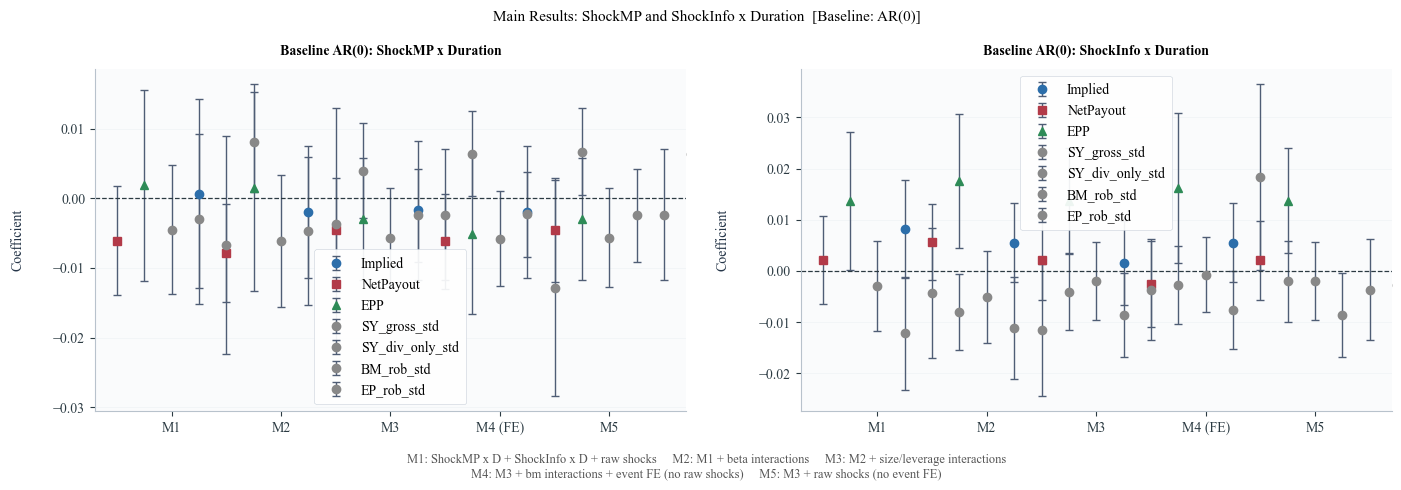

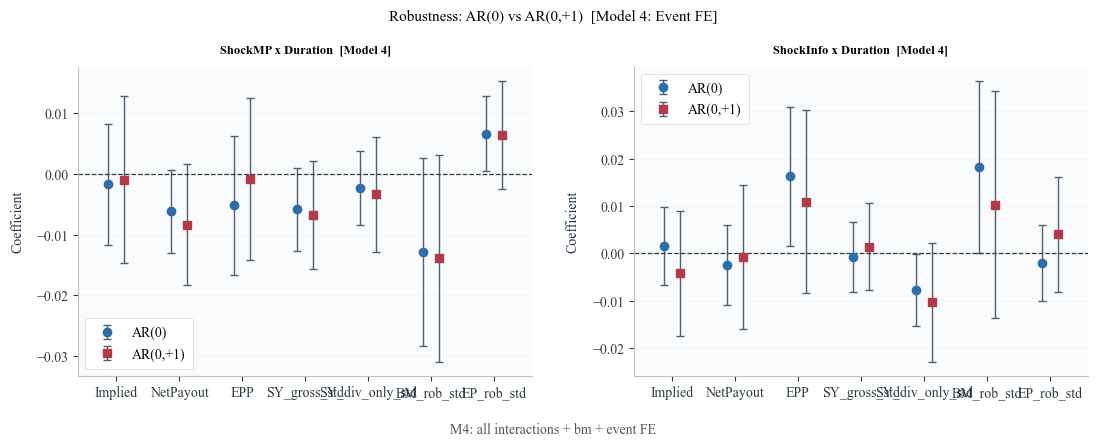

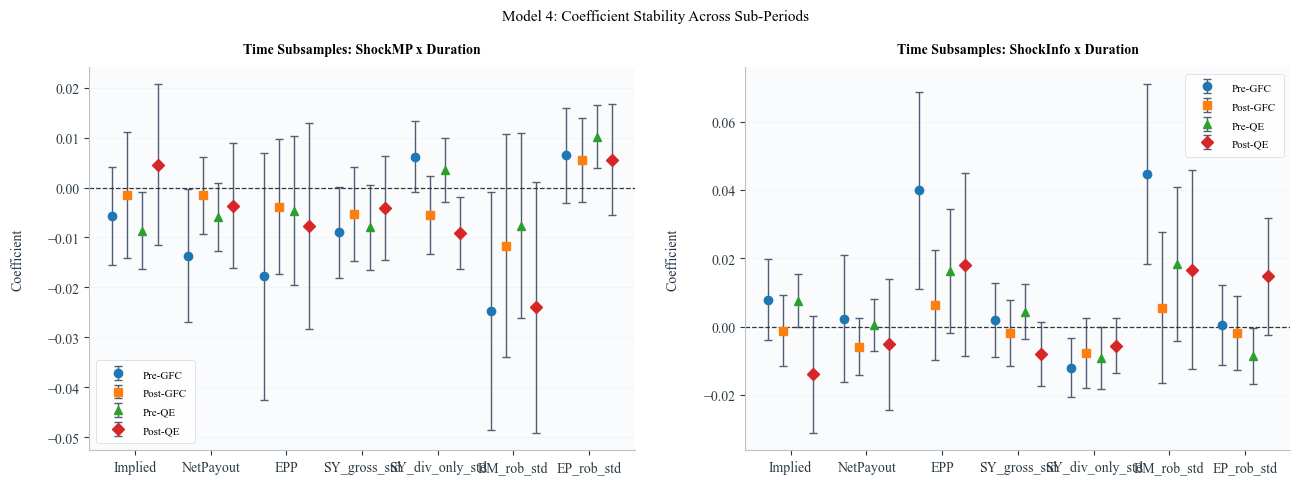

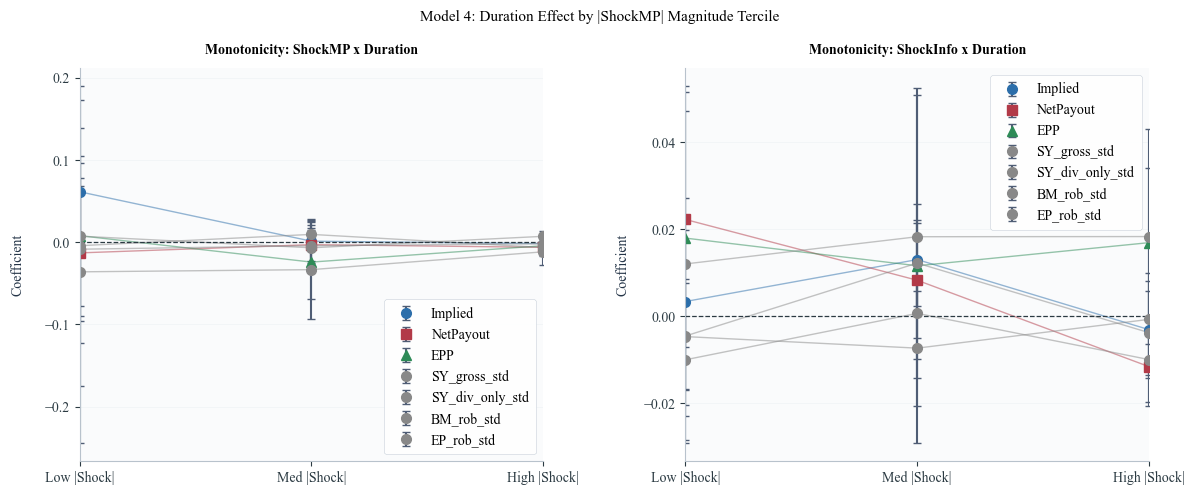

In [51]:
print("=" * 60)
print("SECTION 12: COEFFICIENT PLOTS")
print("=" * 60)

plot_df = df_results.copy()

spec_order_map = {
    'Model 1: Baseline':                 0,
    'Model 2: + beta':                   1,
    'Model 3: + size/leverage':          2,
    'Model 4: Event FE + all controls':  3,
    'Model 5: No Event FE + raw shocks': 4,
}
spec_short = {
    'Model 1: Baseline':                 'M1',
    'Model 2: + beta':                   'M2',
    'Model 3: + size/leverage':          'M3',
    'Model 4: Event FE + all controls':  'M4 (FE)',
    'Model 5: No Event FE + raw shocks': 'M5',
}
dur_short = {
    'Duration_Implied_std':   'Implied',
    'Duration_NetPayout_std': 'NetPayout',
    'EPP_std':             'EPP',
}
dep_short = {'AR_0': 'AR(0)', 'AR_0_1': 'AR(0,+1)'}

_DUR_COLORS = {
    'Duration_Implied_std':   COLORS['blue'],
    'Duration_NetPayout_std': COLORS['accent'],
    'EPP_std':             COLORS.get('green', '#2ca02c'),
}
_DUR_MARKERS = {
    'Duration_Implied_std': 'o',
    'Duration_NetPayout_std': 's',
    'EPP_std': '^',
}

MODEL_NOTE = (
    'M1: ShockMP x D + ShockInfo x D + raw shocks     '
    'M2: M1 + beta interactions     '
    'M3: M2 + size/leverage interactions\n'
    'M4: M3 + bm interactions + event FE (no raw shocks)     '
    'M5: M3 + raw shocks (no event FE)'
)

dur_list = [d for d in ['Duration_Implied_std', 'Duration_NetPayout_std', 'EPP_std',
                          'SY_gross_std', 'SY_div_only_std', 'BM_rob_std', 'EP_rob_std']
            if d in plot_df['duration_name'].values]
n_dur   = len(dur_list)
w       = 0.25   # width per group (three measures)
_offsets = np.linspace(-(n_dur - 1) * w / 2, (n_dur - 1) * w / 2, n_dur)

# ── Main plot: AR_0, all models, all duration measures ────────────────────────
main_df = plot_df[plot_df['depvar'] == 'AR_0'].copy()
main_df['spec_order'] = main_df['specification_name'].map(spec_order_map).fillna(99)
main_df = main_df.sort_values('spec_order')
specs   = main_df['specification_name'].unique()
x       = np.arange(len(specs))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.subplots_adjust(bottom=0.22)

for ax, coef_col, se_col, shock_label in [
    (axes[0], 'coef_mp_duration',   'se_mp_duration',   'ShockMP x Duration'),
    (axes[1], 'coef_info_duration', 'se_info_duration', 'ShockInfo x Duration'),
]:
    for dur, offset in zip(dur_list, _offsets):
        _d = main_df[main_df['duration_name'] == dur].set_index('specification_name').reindex(specs)
        ax.errorbar(x + offset,
                    pd.to_numeric(_d[coef_col], errors='coerce'),
                    yerr=1.96 * pd.to_numeric(_d[se_col], errors='coerce'),
                    fmt=_DUR_MARKERS.get(dur, 'o'), color=_DUR_COLORS.get(dur, '#888'),
                    ecolor=COLORS['neutral'], capsize=3, markersize=6,
                    label=dur_short.get(dur, dur))
    ax.axhline(0, color=COLORS['reference'], linewidth=0.9, linestyle='--')
    ax.set_xticks(x)
    ax.set_xticklabels([spec_short.get(s, s) for s in specs], fontsize=9)
    ax.set_xlim(-0.7, len(specs) - 0.3)
    ax.set_title(f'Baseline AR(0): {shock_label}', fontsize=10)
    ax.set_ylabel('Coefficient')
    style_axes(ax, grid_axis='y', grid_alpha=0.2, label_x=-0.12)
    style_legend(ax, loc='best')

fig.text(0.5, 0.04, MODEL_NOTE, ha='center', va='bottom', fontsize=9, color='#555555')
plt.suptitle('Main Results: ShockMP and ShockInfo x Duration  [Baseline: AR(0)]', fontsize=11)
plt.tight_layout(rect=[0, 0.10, 1, 1], w_pad=3)
fig.savefig(GRAPH_DIR / 'coef_plot_main_ar0.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Robustness: AR(0) vs AR(0,+1), Model 4 ───────────────────────────────────
rob_df = plot_df[plot_df['specification_name'] == 'Model 4: Event FE + all controls'].copy()
x2     = np.arange(len(dur_list))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=False)
fig.subplots_adjust(bottom=0.18)

for ax, coef_col, se_col, title in [
    (axes[0], 'coef_mp_duration',   'se_mp_duration',   'ShockMP x Duration  [Model 4]'),
    (axes[1], 'coef_info_duration', 'se_info_duration', 'ShockInfo x Duration  [Model 4]'),
]:
    for dep, offset, color, marker in [
        ('AR_0',   -w / 2, COLORS['blue'],   'o'),
        ('AR_0_1',  w / 2, COLORS['accent'], 's'),
    ]:
        _d = rob_df[rob_df['depvar'] == dep].set_index('duration_name').reindex(dur_list)
        ax.errorbar(x2 + offset,
                    pd.to_numeric(_d[coef_col], errors='coerce'),
                    yerr=1.96 * pd.to_numeric(_d[se_col], errors='coerce'),
                    fmt=marker, color=color, ecolor=COLORS['neutral'],
                    capsize=3, markersize=6, label=dep_short[dep])
    ax.axhline(0, color=COLORS['reference'], linewidth=0.9, linestyle='--')
    ax.set_xticks(x2)
    ax.set_xticklabels([dur_short.get(d, d) for d in dur_list])
    ax.set_xlim(-0.6, len(dur_list) - 0.4)
    ax.set_title(title, fontsize=9)
    ax.set_ylabel('Coefficient')
    style_axes(ax, grid_axis='y', grid_alpha=0.2, label_x=-0.12)
    style_legend(ax, loc='best')

fig.text(0.5, 0.03,
         'M4: all interactions + bm + event FE',
         ha='center', va='bottom', fontsize=10, color='#555555')
plt.suptitle('Robustness: AR(0) vs AR(0,+1)  [Model 4: Event FE]', fontsize=11)
plt.tight_layout(rect=[0, 0.08, 1, 1], w_pad=3)
fig.savefig(GRAPH_DIR / 'coef_plot_rob_ar0_ar01.png', dpi=300, bbox_inches='tight')
plt.show()

# ── New plot: Time subsamples (if available) ──────────────────────────────────
if 'df_new_robust' in dir() and not df_new_robust.empty:
    _time_labels = ['Pre-GFC (before 2008-09-01)', 'Post-GFC (after 2008-09-01)',
                    'Pre-QE (before 2015-01-22)',  'Post-QE (after 2015-01-22)']
    _time_df = df_new_robust[df_new_robust['subsample'].isin(_time_labels)].copy()
    if not _time_df.empty:
        _sub_colors  = {'Pre-GFC (before 2008-09-01)': '#1f77b4',
                        'Post-GFC (after 2008-09-01)': '#ff7f0e',
                        'Pre-QE (before 2015-01-22)':  '#2ca02c',
                        'Post-QE (after 2015-01-22)':  '#d62728'}
        _sub_markers = {'Pre-GFC (before 2008-09-01)': 'o', 'Post-GFC (after 2008-09-01)': 's',
                        'Pre-QE (before 2015-01-22)':  '^', 'Post-QE (after 2015-01-22)':  'D'}
        _sub_offsets = np.linspace(-0.3, 0.3, 4)
        x3 = np.arange(len(dur_list))
        fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)
        for ax, coef_col, se_col, shock_label in [
            (axes[0], 'coef_mp_duration',   'se_mp_duration',   'ShockMP x Duration'),
            (axes[1], 'coef_info_duration', 'se_info_duration', 'ShockInfo x Duration'),
        ]:
            for (_sub, _off) in zip(_time_labels, _sub_offsets):
                _d = _time_df[_time_df['subsample'] == _sub].set_index('duration_name').reindex(dur_list)
                ax.errorbar(x3 + _off,
                            pd.to_numeric(_d[coef_col], errors='coerce'),
                            yerr=1.96 * pd.to_numeric(_d[se_col], errors='coerce'),
                            fmt=_sub_markers[_sub], color=_sub_colors[_sub],
                            ecolor=COLORS['neutral'], capsize=3, markersize=6,
                            label=_sub.split(' (')[0])
            ax.axhline(0, color=COLORS['reference'], linewidth=0.9, linestyle='--')
            ax.set_xticks(x3)
            ax.set_xticklabels([dur_short.get(d, d) for d in dur_list])
            ax.set_xlim(-0.6, len(dur_list) - 0.4)
            ax.set_title(f'Time Subsamples: {shock_label}', fontsize=10)
            ax.set_ylabel('Coefficient')
            style_axes(ax, grid_axis='y', grid_alpha=0.2, label_x=-0.12)
            style_legend(ax, loc='best')
            _leg = ax.get_legend()
            if _leg: [t.set_fontsize(8) for t in _leg.get_texts()]
        plt.suptitle('Model 4: Coefficient Stability Across Sub-Periods', fontsize=11)
        plt.tight_layout(rect=[0, 0.02, 1, 1], w_pad=3)
        fig.savefig(GRAPH_DIR / 'coef_plot_time_subsamples.png', dpi=300, bbox_inches='tight')
        plt.show()

    # ── New plot: Shock magnitude monotonicity ────────────────────────────────
    _tercile_df = df_new_robust[
        df_new_robust['subsample'].str.startswith('|ShockMP| tercile', na=False)].copy()
    if not _tercile_df.empty:
        _tercile_order = ['Low', 'Med', 'High']
        _x_t = np.arange(3)
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        for ax, coef_col, se_col, shock_label in [
            (axes[0], 'coef_mp_duration',   'se_mp_duration',   'ShockMP x Duration'),
            (axes[1], 'coef_info_duration', 'se_info_duration', 'ShockInfo x Duration'),
        ]:
            for _dur in dur_list:
                _ys, _errs = [], []
                for _t in _tercile_order:
                    _r = _tercile_df[(_tercile_df['duration_name'] == _dur) &
                                     (_tercile_df['subsample'] == f'|ShockMP| tercile: {_t}')]
                    _ys.append(float(_r[coef_col].iloc[0]) if not _r.empty else np.nan)
                    _errs.append(1.96 * float(_r[se_col].iloc[0]) if not _r.empty else np.nan)
                ax.errorbar(_x_t, _ys, yerr=_errs,
                            fmt=_DUR_MARKERS.get(_dur, 'o'), color=_DUR_COLORS.get(_dur, '#888'),
                            ecolor=COLORS['neutral'], capsize=3, markersize=7, linewidth=1.5,
                            label=dur_short.get(_dur, _dur))
                ax.plot(_x_t, _ys, '-', color=_DUR_COLORS.get(_dur, '#888'),
                        linewidth=1.0, alpha=0.5)
            ax.axhline(0, color=COLORS['reference'], linewidth=0.9, linestyle='--')
            ax.set_xticks(_x_t)
            ax.set_xticklabels(['Low |Shock|', 'Med |Shock|', 'High |Shock|'])
            ax.set_title(f'Monotonicity: {shock_label}', fontsize=10)
            ax.set_ylabel('Coefficient')
            style_axes(ax, grid_axis='y', grid_alpha=0.2, label_x=-0.12)
            style_legend(ax, loc='best')
        plt.suptitle('Model 4: Duration Effect by |ShockMP| Magnitude Tercile', fontsize=11)
        plt.tight_layout(w_pad=3)
        fig.savefig(GRAPH_DIR / 'coef_plot_shock_monotonicity.png', dpi=300, bbox_inches='tight')
        plt.show()

## 13. Professional LaTeX Table

Two-panel booktabs table (Panel A: ShockMP × Duration, Panel B: ShockInfo × Duration).
Columns: Implied | NetPayout | EPP. Footer rows: Event FE, N, Adj. R².
Saves to `regression_table_main.tex`.

In [52]:
print("=" * 60)
print("SECTION 13: PROFESSIONAL LaTeX TABLE")
print("=" * 60)

def _tex_stars(p):
    if pd.isna(p): return ''
    if p < 0.01:   return '$^{***}$'
    if p < 0.05:   return '$^{**}$'
    if p < 0.10:   return '$^{*}$'
    return ''

def build_latex_table(results_df, depvar='AR_0', outpath=None):
    _df    = results_df[results_df['depvar'] == depvar].copy()
    _specs = [s for s in ['Model 1: Baseline', 'Model 2: + beta',
                           'Model 3: + size/leverage',
                           'Model 4: Event FE + all controls',
                           'Model 5: No Event FE + raw shocks']
              if s in _df['specification_name'].values]
    _durs  = [d for d in ['Duration_Implied_std', 'Duration_NetPayout_std', 'EPP_std']
              if d in _df['duration_name'].values]
    _dur_labels_tex = [dur_short.get(d, d) for d in _durs]
    _spec_labels_tex = {
        'Model 1: Baseline':                 'M1: Baseline',
        'Model 2: + beta':                   'M2: + beta',
        'Model 3: + size/leverage':          'M3: + size/leverage',
        'Model 4: Event FE + all controls':  'M4: Event FE',
        'Model 5: No Event FE + raw shocks': 'M5: No FE + raw shocks',
    }
    _n_d = len(_durs)
    L = []
    L.append(r'\begin{table}[htbp]')
    L.append(r'\centering\small')
    L.append(
        r'\caption{Equity Duration and ECB Monetary Policy Shocks. '
        r'Dependent variable: Abnormal return on the event day (AR$_{0}$). '
        r'ShockMP (monetary policy surprise, \texttt{MP\_median}) and ShockInfo '
        r'(central bank information shock, \texttt{CBI\_median}) from the ECB MPD '
        r'dataset. Duration measures are standardized cross-sectionally by year '
        r'(sample s.d., ddof\,=\,1). '
        r'Standard errors clustered by event date in parentheses. '
        r'$^{***}p<0.01$, $^{**}p<0.05$, $^{*}p<0.10$.}')
    L.append(r'\label{tab:main_regression}')
    _col_spec = 'l' + 'cc' * _n_d
    L.append(r'\begin{tabular}{' + _col_spec + r'}')
    L.append(r'\toprule')
    # Duration group headers
    L.append(' & ' + ' & '.join(
        [r'\multicolumn{2}{c}{' + _dl + r'}' for _dl in _dur_labels_tex]) + r' \\')
    # cmidrule separators
    L.append(' '.join(
        [r'\cmidrule(lr){' + str(2 + 2*i) + r'-' + str(3 + 2*i) + r'}' for i in range(_n_d)]))
    L.append(' & ' + ' & '.join([r'Coef. & (SE)'] * _n_d) + r' \\')
    L.append(r'\midrule')

    for _panel, _coef_c, _se_c, _p_c in [
        (r'\textit{Panel A: ShockMP $\times$ Duration}',
         'coef_mp_duration', 'se_mp_duration', 'p_mp_duration'),
        (r'\textit{Panel B: ShockInfo $\times$ Duration}',
         'coef_info_duration', 'se_info_duration', 'p_info_duration'),
    ]:
        L.append(r'\multicolumn{' + str(1 + 2*_n_d) + r'}{l}{' + _panel + r'} \\')
        for _spec in _specs:
            _cells = [_spec_labels_tex.get(_spec, _spec)]
            for _dur in _durs:
                _r = _df[(_df['specification_name'] == _spec) & (_df['duration_name'] == _dur)]
                if _r.empty:
                    _cells.extend(['', ''])
                else:
                    _c = _r[_coef_c].iloc[0]
                    _s = _r[_se_c].iloc[0]
                    _p = _r[_p_c].iloc[0]
                    _cells.append(f'{_c:.4f}{_tex_stars(_p)}' if pd.notna(_c) else '')
                    _cells.append(f'({_s:.4f})' if pd.notna(_s) else '')
            L.append(' & '.join(_cells) + r' \\')
        # Footer rows
        L.append(r'\midrule')
        _fe_row, _n_row, _r2_row = ['Event FE'], ['$N$'], ['Adj.\\ $R^{2}$']
        for _dur in _durs:
            _rm4 = _df[(_df['specification_name'] == 'Model 4: Event FE + all controls') &
                       (_df['duration_name'] == _dur)]
            _fe_row.extend(['Yes', ''] if not _rm4.empty else ['No', ''])
            _nv  = int(_rm4['N'].iloc[0]) if not _rm4.empty and pd.notna(_rm4['N'].iloc[0]) else ''
            _n_row.extend([f'{_nv:,}', ''] if _nv != '' else ['', ''])
            _r2v = _rm4['r_squared_adj'].iloc[0] if not _rm4.empty else np.nan
            _r2_row.extend([f'{_r2v:.4f}', ''] if pd.notna(_r2v) else ['', ''])
        L.append(' & '.join(_fe_row)  + r' \\')
        L.append(' & '.join(_n_row)   + r' \\')
        L.append(' & '.join(_r2_row)  + r' \\')
        if _panel.startswith(r'\textit{Panel A'):
            L.append(r'\midrule')
    L.append(r'\bottomrule')
    L.append(r'\end{tabular}')
    L.append(r'\end{table}')
    _latex = '\n'.join(L)
    if outpath:
        Path(outpath).write_text(_latex, encoding='utf-8')
        print(f"Saved: {outpath}")
    return _latex

_tex = build_latex_table(df_results, depvar='AR_0',
                         outpath=TABLE_DIR / 'regression_table_main.tex')
print(_tex[:3000])

SECTION 13: PROFESSIONAL LaTeX TABLE
Saved: /Users/jakob/Documents/Parforceleistung/Studium/MSc Economics/Masterarbeit/Project_Data/tables/regression_table_main.tex
\begin{table}[htbp]
\centering\small
\caption{Equity Duration and ECB Monetary Policy Shocks. Dependent variable: Abnormal return on the event day (AR$_{0}$). ShockMP (monetary policy surprise, \texttt{MP\_median}) and ShockInfo (central bank information shock, \texttt{CBI\_median}) from the ECB MPD dataset. Duration measures are standardized cross-sectionally by year (sample s.d., ddof\,=\,1). Standard errors clustered by event date in parentheses. $^{***}p<0.01$, $^{**}p<0.05$, $^{*}p<0.10$.}
\label{tab:main_regression}
\begin{tabular}{lcccccc}
\toprule
 & \multicolumn{2}{c}{Implied} & \multicolumn{2}{c}{NetPayout} & \multicolumn{2}{c}{EPP} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7}
 & Coef. & (SE) & Coef. & (SE) & Coef. & (SE) \\
\midrule
\multicolumn{7}{l}{\textit{Panel A: ShockMP $\times$ Duration}} \\

## 14. Export output tables

In [53]:
print("=" * 60)
print("SECTION 14: EXPORT OUTPUT TABLES")
print("=" * 60)

# ── Wald tests ────────────────────────────────────────────────────────────────
wald_rows = []
for _, r in df_results.iterrows():
    res       = r['model_obj']
    dur       = r['duration_name']
    mp_term   = f'ShockMP:{dur}'
    info_term = f'ShockInfo:{dur}'
    if mp_term not in res.params.index or info_term not in res.params.index:
        continue
    names    = list(res.params.index)
    n_params = len(names)

    # Wald test 1: H0: beta_MP_duration = beta_Info_duration (equality test)
    R1 = np.zeros((1, n_params))
    R1[0, names.index(mp_term)]   =  1.0
    R1[0, names.index(info_term)] = -1.0
    wt1 = res.wald_test(R1, scalar=True)

    # Wald test 2 (NEW): H0: beta_MP_duration = 0 AND beta_Info_duration = 0 (joint significance)
    R2 = np.zeros((2, n_params))
    R2[0, names.index(mp_term)]   = 1.0
    R2[1, names.index(info_term)] = 1.0
    wt2 = res.wald_test(R2, scalar=False)

    beta_mp   = float(res.params[mp_term])
    beta_info = float(res.params[info_term])
    wald_rows.append({
        'Duration':                  dur.replace('_std', '').replace('Duration_', ''),
        'Return window':             r['depvar'],
        'Specification':             r['specification_name'],
        'beta_MP':                   beta_mp,
        'beta_Info':                 beta_info,
        'difference':                beta_mp - beta_info,
        'Wald1_p (MP=Info)':         float(wt1.pvalue),
        'Wald2_p (MP=0 & Info=0)':   float(wt2.pvalue),
    })

TABLE_DIR.mkdir(parents=True, exist_ok=True)

regression_results_main   = df_results.drop(columns=['model_obj']).copy()
regression_results_reader = TABLE_READER.copy()
regression_results_wald   = pd.DataFrame(wald_rows)

# Combined robustness results
_all_robust = []
if 'df_robust' in dir() and not df_robust.empty:
    _all_robust.append(df_robust.drop(columns=['model_obj'], errors='ignore').copy())
if 'df_new_robust' in dir() and not df_new_robust.empty:
    _all_robust.append(df_new_robust.drop(columns=['model_obj'], errors='ignore').copy())
regression_results_robust = (pd.concat(_all_robust, ignore_index=True)
                             if _all_robust else pd.DataFrame())

# Subsample results (time + shock magnitude)
if 'new_robust_rows' in dir() and new_robust_rows:
    regression_results_subsamples = (
        pd.DataFrame(new_robust_rows)
        .drop(columns=['model_obj'], errors='ignore').copy())
else:
    regression_results_subsamples = pd.DataFrame()

# Write CSVs
regression_results_main.to_csv(TABLE_DIR / 'regression_results_main.csv', index=False)
regression_results_reader.to_csv(TABLE_DIR / 'regression_results_reader.csv', index=False)
regression_results_wald.to_csv(TABLE_DIR / 'regression_results_wald.csv', index=False)
if not regression_results_robust.empty:
    regression_results_robust.to_csv(TABLE_DIR / 'regression_results_robust.csv', index=False)
if not regression_results_subsamples.empty:
    regression_results_subsamples.to_csv(TABLE_DIR / 'regression_results_subsamples.csv', index=False)

print('Exported CSV files:')
for _f in ['regression_results_main.csv', 'regression_results_reader.csv',
           'regression_results_wald.csv', 'regression_results_robust.csv',
           'regression_results_subsamples.csv',
           'regression_results_portfolio_q20q80.csv']:
    _fp = TABLE_DIR / _f
    _status = f'{_fp.stat().st_size:,} bytes' if _fp.exists() else 'not created'
    print(f'  {_f}: {_status}')

display(regression_results_wald.round(4))

SECTION 14: EXPORT OUTPUT TABLES
Exported CSV files:
  regression_results_main.csv: 26,359 bytes
  regression_results_reader.csv: 8,854 bytes
  regression_results_wald.csv: 10,162 bytes
  regression_results_robust.csv: 56,283 bytes
  regression_results_subsamples.csv: 32,598 bytes
  regression_results_portfolio_q20q80.csv: 3,545 bytes


,Duration,Return window,Specification,beta_MP,beta_Info,difference,Wald1_p (MP=Info),Wald2_p (MP=0 & Info=0)
0,Implied,AR_0,Model 1: Baseline,0.0008,0.0068,-0.0060,0.5552,0.2159
1,Implied,AR_0,Model 2: + beta,0.0007,0.0082,-0.0075,0.4612,0.1375
2,Implied,AR_0,Model 3: + size/leverage,-0.0020,0.0056,-0.0075,0.3092,0.3659
3,Implied,AR_0,Model 4: Event FE + all controls,-0.0017,0.0015,-0.0032,0.6809,0.9180
4,Implied,AR_0,Model 5: No Event FE + raw shocks,-0.0020,0.0056,-0.0075,0.3092,0.3659
...,...,...,...,...,...,...,...,...
65,EP_rob,AR_0_1,Model 1: Baseline,0.0060,-0.0034,0.0094,0.2959,0.5240
66,EP_rob,AR_0_1,Model 2: + beta,0.0025,0.0003,0.0022,0.7961,0.8600
67,EP_rob,AR_0_1,Model 3: + size/leverage,0.0050,0.0015,0.0035,0.6672,0.4979
68,EP_rob,AR_0_1,Model 4: Event FE + all controls,0.0064,0.0040,0.0024,0.7541,0.2933


In [54]:
print("=" * 60)
print("FINAL REGRESSION DIAGNOSTICS SUMMARY")
print("=" * 60)

print(f"\nTotal unique events used: {df_evt['event_date'].nunique()}")

print("\nModel 4 — observations per duration variable:")
for _dur in duration_vars:
    _m4 = df_results[(df_results['specification_name'] == 'Model 4: Event FE + all controls') &
                     (df_results['duration_name'] == _dur) &
                     (df_results['depvar'] == 'AR_0')]
    if not _m4.empty:
        print(f"  {_dur}: N={int(_m4['N'].iloc[0]):,}, "
              f"n_events={int(_m4['n_events'].iloc[0])}, "
              f"n_clusters={int(_m4['n_clusters'].iloc[0])}, "
              f"Adj.R2={float(_m4['r_squared_adj'].iloc[0]):.4f}")

print("\nCluster count summary across all AR_0 specifications:")
_ar0_res = df_results[df_results['depvar'] == 'AR_0']
if 'n_clusters' in _ar0_res.columns:
    _nc = _ar0_res['n_clusters'].dropna().astype(int)
    print(f"  Min: {_nc.min()}   Median: {_nc.median():.0f}   Max: {_nc.max()}")
    _below30 = _ar0_res[_ar0_res['n_clusters'] < 30]
    if not _below30.empty:
        print("  FLAGGED (n_clusters < 30):")
        for _, _r in _below30.iterrows():
            print(f"    {_r['specification_name']} / {_r['duration_name']}: "
                  f"n_clusters={int(_r['n_clusters'])}")
    else:
        print("  All specifications have >=30 clusters — clustered SEs reliable.")

print("\nNaN standard error check:")
_nan_se = df_results[df_results['se_mp_duration'].isna() | df_results['se_info_duration'].isna()]
if not _nan_se.empty:
    print("  WARNING: NaN SEs in:")
    for _, _r in _nan_se.iterrows():
        print(f"    {_r['specification_name']} / {_r['duration_name']}")
else:
    print("  No NaN standard errors detected.")

print("\n" + "=" * 60)
print("THESIS EXPORT COMPLETE")
print("=" * 60)
for _f in ['regression_results_main.csv', 'regression_results_reader.csv',
           'regression_results_wald.csv', 'regression_results_robust.csv',
           'regression_results_subsamples.csv', 'regression_table_main.tex']:
    _fp = TABLE_DIR / _f
    if _fp.exists():
        _rows = ''
        if _f.endswith('.csv'):
            try:
                _rows = f"{len(pd.read_csv(_fp))} rows, "
            except Exception:
                pass
        print(f"  {_f}: {_rows}{_fp.stat().st_size:,} bytes")
    else:
        print(f"  {_f}: NOT FOUND")

print("\nGraph files:")
for _g in ['duration_coverage_by_event.png', 'coef_plot_main_ar0.png',
           'coef_plot_rob_ar0_ar01.png', 'coef_plot_time_subsamples.png',
           'coef_plot_shock_monotonicity.png']:
    _gp = GRAPH_DIR / _g
    _st = f"{_gp.stat().st_size:,} bytes" if _gp.exists() else "not created"
    print(f"  {_g}: {_st}")

FINAL REGRESSION DIAGNOSTICS SUMMARY

Total unique events used: 312

Model 4 — observations per duration variable:
  Duration_Implied_std: N=105,297, n_events=312, n_clusters=312, Adj.R2=0.0848
  Duration_NetPayout_std: N=103,200, n_events=312, n_clusters=312, Adj.R2=0.0812
  EPP_std: N=112,388, n_events=312, n_clusters=312, Adj.R2=0.0843
  SY_gross_std: N=106,224, n_events=312, n_clusters=312, Adj.R2=0.0815
  SY_div_only_std: N=98,709, n_events=312, n_clusters=312, Adj.R2=0.0894
  BM_rob_std: N=115,130, n_events=312, n_clusters=312, Adj.R2=0.0845
  EP_rob_std: N=114,848, n_events=312, n_clusters=312, Adj.R2=0.0841

Cluster count summary across all AR_0 specifications:
  Min: 312   Median: 312   Max: 312
  All specifications have >=30 clusters — clustered SEs reliable.

NaN standard error check:
  No NaN standard errors detected.

THESIS EXPORT COMPLETE
  regression_results_main.csv: 70 rows, 26,359 bytes
  regression_results_reader.csv: 70 rows, 8,854 bytes
  regression_results_wald.c

## Interpretation Notes

- `ShockMP × Duration`: under tightening surprises, a more negative coefficient is consistent with stronger losses for long-duration equities.
- `ShockInfo × Duration`: sign is ambiguous a priori because information shocks can combine discount-rate and cash-flow effects.
- Event FE models isolate within-event cross-sectional variation across firms.
- No Event FE models additionally use cross-event variation in shock magnitudes.